## Import

In [175]:
import numpy as np
import scipy
from scipy import signal
from scipy.signal import hilbert
from scipy import integrate
from pathlib import Path
from scipy.interpolate import UnivariateSpline

try:
    from scipy.integrate import simps
except ImportError:
    from scipy.integrate import simpson

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob
import subprocess
import math

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'serif'
import matplotlib


# VERY CAREFULLY not to delete other folders!
if os.path.isdir("thesis_plots"):
    shutil.rmtree("thesis_plots")
    print("thesis_plots folder is deleted and created again")
    print(" ")

os.makedirs("thesis_plots", exist_ok=True)

os.makedirs("thesis_plots/dos", exist_ok=True)
os.makedirs("thesis_plots/dos/png", exist_ok=True)
os.makedirs("thesis_plots/dos/pdf", exist_ok=True)

os.makedirs("thesis_plots/energy", exist_ok=True)
os.makedirs("thesis_plots/energy/z", exist_ok=True)
os.makedirs("thesis_plots/energy/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/energy/z/png", exist_ok=True)

os.makedirs("thesis_plots/energy/x", exist_ok=True)
os.makedirs("thesis_plots/energy/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/energy/x/png", exist_ok=True)


os.makedirs("thesis_plots/current", exist_ok=True)
os.makedirs("thesis_plots/current/z", exist_ok=True)
os.makedirs("thesis_plots/current/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/current/z/png", exist_ok=True)

os.makedirs("thesis_plots/current/x", exist_ok=True)
os.makedirs("thesis_plots/current/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/current/x/png", exist_ok=True)

os.makedirs("thesis_plots/hhg", exist_ok=True)
os.makedirs("thesis_plots/hhg/z", exist_ok=True)
os.makedirs("thesis_plots/hhg/z/pdf", exist_ok=True)
os.makedirs("thesis_plots/hhg/z/png", exist_ok=True)

os.makedirs("thesis_plots/hhg/x", exist_ok=True)
os.makedirs("thesis_plots/hhg/x/pdf", exist_ok=True)
os.makedirs("thesis_plots/hhg/x/png", exist_ok=True)

os.makedirs("thesis_plots/cco", exist_ok=True)
os.makedirs("thesis_plots/cco/pdf", exist_ok=True)
os.makedirs("thesis_plots/cco/png", exist_ok=True)

os.makedirs("thesis_plots/drude", exist_ok=True)
os.makedirs("thesis_plots/drude/pdf", exist_ok=True)
os.makedirs("thesis_plots/drude/png", exist_ok=True)


thesis_plots folder is deleted and created again
 


## get tree

In [2]:
result = subprocess.run(
    ["find", ".", "-mindepth", "6", "-maxdepth", "6", "-type", "d"],
    cwd="all_data/main",
    capture_output=True,
    text=True
)

# print(result.stdout)

all_data_folders = [
    line[2:] if line.startswith("./") else line
    for line in result.stdout.strip().split("\n")
]

# print(all_data_folders)

tree = {}

for path in all_data_folders:
    parts = path.split("/")
    
    levels = parts[:5]              # 5 уровней вложенности
    full_folder_name = path         # значение
    
    current = tree
    
    for part in levels[:-1]:        # идём до 4-го уровня
        current = current.setdefault(part, {})
    
    # 5-й уровень → присваиваем строку
    current[levels[-1]] = full_folder_name

# print(tree)

# tree['1eV']['sigma']['21fs']['4d10']['1d12']
# exists = tree.get('1eV', {}).get('sigma', {}).get('21fs', {}).get('4d10', {}).get('1d12') is not None

In [3]:
folder1 = 'all_data/main/'+tree['1eV']['sigma']['21fs']['4d10']['1d12']
folder2 = 'all_data/main/'+tree['1eV']['amorphous']['21fs']['4d10']['1d12']


folder3 = 'all_data/main/'+tree['1.5eV']['sigma']['21fs']['4d10']['5d11']
folder4 = []
if(tree.get('1.5eV', {}).get('amorphous', {}).get('21fs', {}).get('4d10', {}).get('5d11') is not None):
    folder4 = 'all_data/main/'+tree['1.5eV']['amorphous']['21fs']['4d10']['5d11']

folder5 = 'all_data/main/'+tree['2eV']['sigma']['21fs']['4d10']['6d11']
folder6 = 'all_data/main/'+tree['2eV']['amorphous']['21fs']['4d10']['6d11']

main_folders=[folder1, folder2, folder3, folder4, folder5, folder6]

folder7 = 'all_data/main/'+tree['1.5eV']['sigma']['12fs']['9d10']['5d11']
folder8 = 'all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

folder9 = 'all_data/main/'+tree['1eV']['sigma']['21fs']['1.5d11']['1d12']


folder_crystal_1 = 'all_data/main/'+tree['1eV']['crystal']['21fs']['4d10']['1d12']

## functions

In [4]:
def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

In [5]:
def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

In [6]:
def extract_amorphous_value(name):
    tokens = name.split("_")
    for i, token in enumerate(tokens):
        if token == "amorphous" and i + 1 < len(tokens):
            return float(tokens[i + 1])

In [7]:
def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return float(match.group(1).replace("d", "e"))

## dos

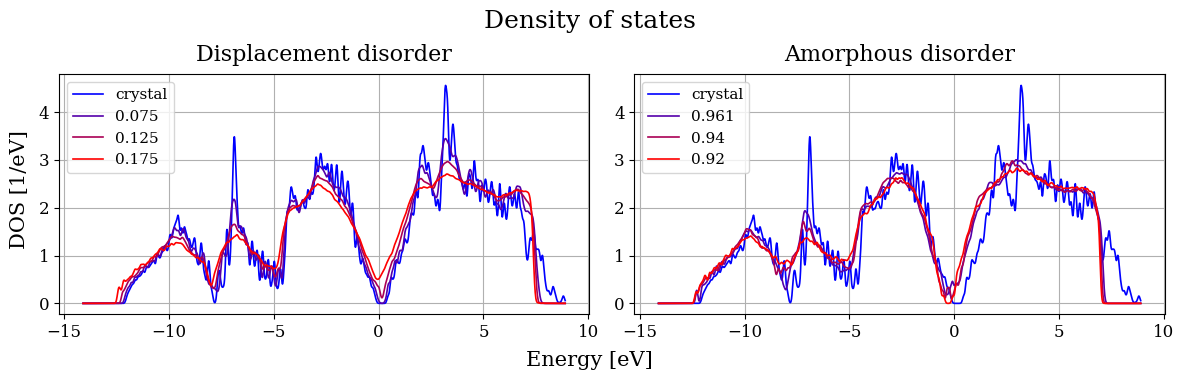

In [8]:
# ==========================================
# Настройки шрифтов
# ==========================================

label_fontsize = 15
tick_fontsize = 12
legend_fontsize = 11
title_fontsize = 16
suptitle_fontsize = 18


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

# ==========================================
# 🔵 Первый график — Crystal (averaged)
# ==========================================

colors = blue_red_gradient(4)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# Reference crystal
ax1.plot(df['energy']-6.1, df['dos'],
         label='crystal',
         linewidth=1.2,
         color=colors[0])

i = 0
for j in range(7):

    if (j % 2 == 0) and j!=0:

        dos_arr = []

        for main_folder in [folder1, folder3, folder5, folder7, folder9]:
            

            files_path = Path(main_folder) / "dos" / "data"
            filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
            df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')
            dos_arr.append(np.array(df_temp['dos']))

        dos_mean = np.mean(dos_arr, axis=0)

        ax1.plot(df_temp['energy']-6.1, dos_mean,
                 linewidth=1.2,
                 label=extract_s_num(filenames_arr[j]),
                 color=colors[i+1])

        i += 1

ax1.set_title("Displacement disorder", fontsize=title_fontsize, y=1.02)
ax1.grid(True)
ax1.legend(fontsize=legend_fontsize)


# ==========================================
# 🔴 Второй график — Amorphous
# ==========================================

colors = blue_red_gradient(4)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# Reference crystal
ax2.plot(df['energy']-6.1, df['dos'],
         label='crystal',
         linewidth=1.2,
         color=colors[0])

i = 0
for j in range(7):

    if (j % 2 == 0) and j!=0:

        files_path = Path(folder2) / "dos" / "data"
        filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
        df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')

        ax2.plot(df_temp['energy']-6.1, df_temp['dos'],
                 linewidth=1.2,
                 label=extract_amorphous_value(filenames_arr[j][:-4]),
                 color=colors[i+1])

        i += 1

ax2.set_title("Amorphous disorder", fontsize=title_fontsize, y=1.02)
ax2.grid(True)
ax2.legend(fontsize=legend_fontsize)


# ==========================================
# Общие подписи
# ==========================================

fig.supxlabel("Energy [eV]", fontsize=label_fontsize, y=0.05)
fig.supylabel("DOS [1/eV]", fontsize=label_fontsize, x=0.017)

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

fig.suptitle("Density of states",
             fontsize=suptitle_fontsize, y=0.95)

plt.tight_layout()

plt.savefig("thesis_plots/dos/png/dos_comparison.png", dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/dos/pdf/dos_comparison.pdf", bbox_inches="tight")

plt.show()
plt.close()

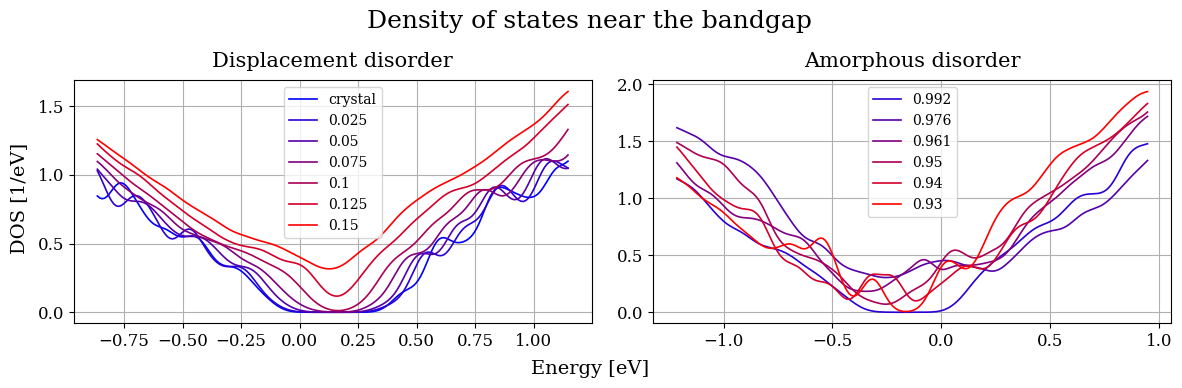

In [9]:
# ==========================================
# Настройки шрифтов
# ==========================================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 10
title_fontsize = 15
suptitle_fontsize = 18


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

emin=1323
emax=1525
# ==========================================
# 🔵 Первый график — Crystal (averaged)
# ==========================================

colors = blue_red_gradient(7)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# Reference crystal
ax1.plot(df['energy'][emin:emax]-6.1, df['dos'][emin:emax],
         label='crystal',
         linewidth=1.2,
         color=colors[0])

i = 0
for j in range(7):

    if j<6:

        dos_arr = []

        for main_folder in [folder1, folder3, folder5, folder7, folder9]:
            

            files_path = Path(main_folder) / "dos" / "data"
            filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
            df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')
            dos_arr.append(np.array(df_temp['dos']))

        dos_mean = np.mean(dos_arr, axis=0)

        ax1.plot(df_temp['energy'][emin:emax]-6.1, dos_mean[emin:emax],
                 linewidth=1.2,
                 label=extract_s_num(filenames_arr[j]),
                 color=colors[i+1])
        # ax1.set_yscale('log')

        i += 1

ax1.set_title("Displacement disorder", fontsize=title_fontsize, y=1.02)
ax1.grid(True)
ax1.legend(fontsize=legend_fontsize)


# ==========================================
# 🔴 Второй график — Amorphous
# ==========================================

shift_add=35

colors = blue_red_gradient(7)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# # Reference crystal
# ax2.plot(df['energy'][(emin-shift_add):emax]-6.1, df['dos'][(emin-shift_add):emax],
#          label='crystal',
#          linewidth=1.2,
#          color=colors[0])

i = 0
for j in range(7):

    if j<6:

        files_path = Path(folder2) / "dos" / "data"
        filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
        df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')

        ax2.plot(df_temp['energy'][(emin-shift_add):emax-20]-6.1, df_temp['dos'][(emin-shift_add):emax-20],
                 linewidth=1.2,
                 label=extract_amorphous_value(filenames_arr[j][:-4]),
                 color=colors[i+1])
        # ax2.set_yscale('log')

        i += 1

ax2.set_title("Amorphous disorder", fontsize=title_fontsize, y=1.02)
ax2.grid(True)
ax2.legend(fontsize=legend_fontsize)


# ==========================================
# Общие подписи
# ==========================================

fig.supxlabel("Energy [eV]", fontsize=label_fontsize, y=0.05)
fig.supylabel("DOS [1/eV]", fontsize=label_fontsize, x=0.017)

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

fig.suptitle("Density of states near the bandgap",
             fontsize=suptitle_fontsize, y=0.97)

plt.tight_layout()

plt.savefig("thesis_plots/dos/png/dos_comparison_bandgap.png", dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/dos/pdf/dos_comparison_bandgap.pdf", bbox_inches="tight")

plt.show()
plt.close()

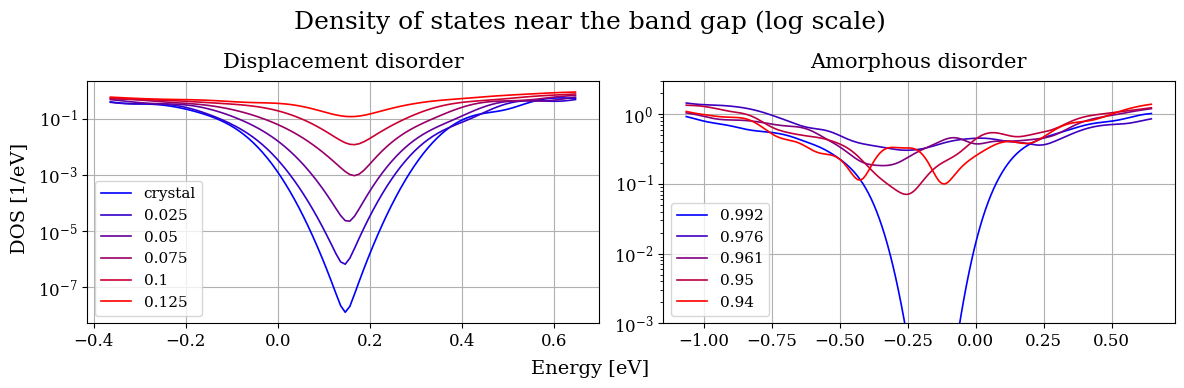

In [10]:
# ==========================================
# Настройки шрифтов
# ==========================================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11
title_fontsize = 15
suptitle_fontsize = 18


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

emin=1373
emax=1475
# ==========================================
# 🔵 Первый график — Crystal (averaged)
# ==========================================

colors = blue_red_gradient(6)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# Reference crystal
ax1.plot(df['energy'][emin:emax]-6.1, df['dos'][emin:emax],
         label='crystal',
         linewidth=1.2,
         color=colors[0])

i = 0
for j in range(7):

    if j<5:

        dos_arr = []

        for main_folder in [folder1, folder3, folder5, folder7, folder9]:
            

            files_path = Path(main_folder) / "dos" / "data"
            filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
            df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')
            dos_arr.append(np.array(df_temp['dos']))

        dos_mean = np.mean(dos_arr, axis=0)

        ax1.plot(df_temp['energy'][emin:emax]-6.1, dos_mean[emin:emax],
                 linewidth=1.2,
                 label=extract_s_num(filenames_arr[j]),
                 color=colors[i+1])
        ax1.set_yscale('log')

        i += 1

ax1.set_title("Displacement disorder", fontsize=title_fontsize, y=1.02)
ax1.grid(True)
ax1.legend(fontsize=legend_fontsize, loc='lower left')


# ==========================================
# 🔴 Второй график — Amorphous
# ==========================================

shift_add=70

emin=1373
emax=1475

colors = blue_red_gradient(5)

files_path = Path(folder_crystal_1) / "dos" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# # Reference crystal
# ax2.plot(df['energy'][(emin-shift_add):emax]-6.1, df['dos'][(emin-shift_add):emax],
#          label='crystal',
#          linewidth=1.2,
#          color=colors[0])

i = 0
for j in range(7):

    if j<5:

        files_path = Path(folder2) / "dos" / "data"
        filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
        df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')

        ax2.plot(df_temp['energy'][(emin-shift_add):emax]-6.1, df_temp['dos'][(emin-shift_add):emax],
                 linewidth=1.2,
                 label=extract_amorphous_value(filenames_arr[j][:-4]),
                 color=colors[i])
        ax2.set_yscale('log')
        ax2.set_ylim(1e-3, 3)

        i += 1

ax2.set_title("Amorphous disorder", fontsize=title_fontsize, y=1.02)
ax2.grid(True)
ax2.legend(fontsize=legend_fontsize, loc='lower left')


# ==========================================
# Общие подписи
# ==========================================

fig.supxlabel("Energy [eV]", fontsize=label_fontsize, y=0.05)
fig.supylabel("DOS [1/eV]", fontsize=label_fontsize, x=0.017)

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

fig.suptitle("Density of states near the band gap (log scale)",
             fontsize=suptitle_fontsize, y=0.97)

plt.tight_layout()

plt.savefig("thesis_plots/dos/png/dos_comparison_bandgap_log.png", dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/dos/pdf/dos_comparison_bandgap_log.pdf", bbox_inches="tight")

plt.show()
plt.close()

In [11]:
def l2_normalize(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    a = np.dot(x, y) / np.dot(x, x)
    return a, a*x

In [12]:
# NEW

import numpy as np
import matplotlib.pyplot as plt

def fit_urbach_energy(E, dos, Emin, Emax, *, log_base="e", min_positive=None,
                      make_plots=True, n_parts=5, plot_parts=False):
    """
    Fit Urbach tail on [Emin, Emax] by linear fit of log(DOS) vs E.

    Parts logic (as requested):
    - Split [Emin, Emax] into n_parts equal energy sub-windows.
    - Fit each part in log-space to get slopes m_i (in ln-units) and their std sigma_m_i.
    - Compute:
        m_parts_mean = mean(m_i)
        m_parts_std  = std(m_i)  (sample std, ddof=1)
      then convert to:
        EU_from_mean_slope = 1 / m_parts_mean
        EU_from_mean_slope_std = m_parts_std / (m_parts_mean^2)
      (i.e., average slopes first, NOT EU_i).

    Also returns global fit EU and its propagated std (from global slope std).

    Returns
    -------
    dict includes:
      - EU_eV, EU_std_eV (global)
      - slopes_parts_ln, slopes_parts_ln_std (per-part)
      - slope_parts_mean_ln, slope_parts_std_ln
      - EU_parts_from_mean_slope_eV, EU_parts_from_mean_slope_std_eV
    """
    E = np.asarray(E, dtype=float)
    dos = np.asarray(dos, dtype=float)

    # --- window + finite ---
    mask_win = (E >= Emin) & (E <= Emax) & np.isfinite(E) & np.isfinite(dos)
    Ew = E[mask_win]
    dw = dos[mask_win]
    if Ew.size < 3:
        raise ValueError("Too few points in the selected window. Need at least 3 points.")

    # --- sort by energy ---
    order = np.argsort(Ew)
    Ew = Ew[order]
    dw = dw[order]

    # --- remove duplicate energies ---
    _, uniq_idx = np.unique(Ew, return_index=True)
    Ew = Ew[uniq_idx]
    dw = dw[uniq_idx]
    if Ew.size < 3:
        raise ValueError("Too few unique energy points in window after removing duplicates.")

    # --- keep positive DOS for log ---
    mask_pos = dw > 0
    x = Ew[mask_pos]
    dpos = dw[mask_pos]
    if x.size < 3:
        raise ValueError("Too few positive DOS points in the selected window. Need >= 3 points.")

    # --- floor to avoid log(0) ---
    if min_positive is None:
        min_positive = np.min(dpos[dpos > 0])
    dpos = np.maximum(dpos, min_positive)

    # --- log transform (this is what is fitted) ---
    if log_base == "e":
        y = np.log(dpos)
        log_label = "ln(DOS)"
        slope_to_ln = 1.0
    elif log_base == "10":
        y = np.log10(dpos)
        log_label = "log10(DOS)"
        slope_to_ln = np.log(10.0)  # m_ln = m_log10 * ln(10)
    else:
        raise ValueError("log_base must be 'e' or '10'.")

    # -----------------------
    # Global linear fit + std
    # -----------------------
    p, cov = np.polyfit(x, y, deg=1, cov=True)
    m, b = p
    sigma_m = float(np.sqrt(cov[0, 0]))

    yhat = m * x + b
    residuals = y - yhat
    N = len(x)

    rmse_log = float(np.sqrt(np.sum(residuals**2) / (N - 2)))
    ss_res = float(np.sum(residuals**2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    m_ln = float(m * slope_to_ln)
    sigma_m_ln = float(sigma_m * slope_to_ln)

    EU = float(1.0 / m_ln)
    EU_std = float(sigma_m_ln / (m_ln**2))

    # -----------------------------------------
    # Split window into parts: fit slopes m_i
    # -----------------------------------------
    edges = np.linspace(Emin, Emax, n_parts + 1)

    slopes_parts_ln = np.full(n_parts, np.nan, dtype=float)
    slopes_parts_ln_std = np.full(n_parts, np.nan, dtype=float)
    parts_n = np.zeros(n_parts, dtype=int)

    for k in range(n_parts):
        a, c = edges[k], edges[k + 1]
        mk = (x >= a) & (x <= c)
        xk = x[mk]
        yk = y[mk]
        parts_n[k] = int(xk.size)

        # need at least 3 points to estimate covariance
        if xk.size < 3:
            continue

        try:
            pk, covk = np.polyfit(xk, yk, deg=1, cov=True)
            mk_slope = float(pk[0])
            sigma_mk = float(np.sqrt(covk[0, 0]))

            slopes_parts_ln[k] = mk_slope * slope_to_ln
            slopes_parts_ln_std[k] = sigma_mk * slope_to_ln
        except np.linalg.LinAlgError:
            continue

    valid = np.isfinite(slopes_parts_ln)
    if np.sum(valid) >= 2:
        slope_parts_mean_ln = float(np.mean(slopes_parts_ln[valid]))
        slope_parts_std_ln = float(np.std(slopes_parts_ln[valid], ddof=1))  # sample std across parts

        EU_parts_from_mean_slope = float(1.0 / slope_parts_mean_ln)
        EU_parts_from_mean_slope_std = float(slope_parts_std_ln / (slope_parts_mean_ln**2))
    elif np.sum(valid) == 1:
        slope_parts_mean_ln = float(slopes_parts_ln[valid][0])
        slope_parts_std_ln = np.nan
        EU_parts_from_mean_slope = float(1.0 / slope_parts_mean_ln)
        EU_parts_from_mean_slope_std = np.nan
    else:
        slope_parts_mean_ln = np.nan
        slope_parts_std_ln = np.nan
        EU_parts_from_mean_slope = np.nan
        EU_parts_from_mean_slope_std = np.nan

    # --------------
    # Plots
    # --------------
    if make_plots:
        # DOS
        plt.figure()
        safe_dos = np.maximum(dos, np.nanmin(dos[dos > 0]) if np.any(dos > 0) else 1e-300)
        plt.semilogy(E, safe_dos, label="DOS")
        plt.axvspan(Emin, Emax, alpha=0.2, label="window")
        plt.xlabel("E (eV)")
        plt.ylabel("DOS (log axis)")
        plt.title("DOS with selected window")
        plt.legend()
        plt.tight_layout()

        # log(DOS) + global fit + part boundaries
        plt.figure()
        plt.plot(x, y, ".", label=log_label)
        plt.plot(x, yhat, "-", label=f"global slope={m:.4g}±{sigma_m:.2g}, R²={R2:.4f}")
        if plot_parts:
            for e in edges[1:-1]:
                plt.axvline(e, linestyle="--")
        plt.xlabel("E (eV)")
        plt.ylabel(log_label)
        plt.title(
            f"Global: EU = {EU:.4g} ± {EU_std:.2g} eV | RMSE(log)={rmse_log:.3g}\n"
            f"Parts({n_parts}) avg-slope: EU = {EU_parts_from_mean_slope:.4g} ± {EU_parts_from_mean_slope_std:.2g} eV"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        # Global
        "EU_eV": EU,
        "EU_std_eV": EU_std,
        "slope_ln": m_ln,
        "slope_ln_std": sigma_m_ln,
        "R2": float(R2),
        "rmse_log": rmse_log,

        # Parts (average slopes first)
        "parts_edges": edges,
        "parts_n": parts_n,
        "slopes_parts_ln": slopes_parts_ln,               # m_i in ln-units
        "slopes_parts_ln_std": slopes_parts_ln_std,       # std(m_i) from each part fit
        "slope_parts_mean_ln": slope_parts_mean_ln,       # mean(m_i)
        "slope_parts_std_ln": slope_parts_std_ln,         # std across parts (model/curvature indicator)

        "EU_parts_from_mean_slope_eV": EU_parts_from_mean_slope,          # 1/mean(m_i)
        "EU_parts_from_mean_slope_std_eV": EU_parts_from_mean_slope_std,  # std(m_i)/mean(m_i)^2

        # Fit data
        "E_fit": x,
        "logDOS": y,
        "logDOS_fit": yhat,
    }

# Example:
# res = fit_urbach_energy(E, dos, Emin=-0.7, Emax=0.0, log_base="e", make_plots=True, n_parts=5, plot_parts=True)
# print("EU global:", res["EU_eV"], "+/-", res["EU_std_eV"])
# print("EU from mean slope:", res["EU_parts_from_mean_slope_eV"], "+/-", res["EU_parts_from_mean_slope_std_eV"])

In [13]:
# ens = np.linspace(2, 3, 100)
# dos = np.exp(ens)
# # plt.plot(ens, dos)

# res = fit_urbach_energy(ens, dos, Emin=2, Emax=3, log_base="e", make_plots=True)
# print("EU (eV) =", res["EU_eV"], "R2 =", res["R2"])

EU (eV) = -0.33661335077669985 E_U std = 0.018364196148666447
parts results mean eV:  -0.25604684046933673
parts results std eV:  0.27178344437412433
EU (eV) = -0.5090812312315012 E_U std = 0.014139276936517215
parts results mean eV:  -0.41047257598210657
parts results std eV:  0.26598436257660435
EU (eV) = -0.6614293400901339 E_U std = 0.007356422966842851
parts results mean eV:  -0.666723716988475
parts results std eV:  0.09958014896555491
EU (eV) = -0.7348895693589395 E_U std = 0.006580077564304654
parts results mean eV:  -0.6955233769477404
parts results std eV:  0.15955859275860182
1.1038481062950514
EU (eV) = -0.24117153895360044 E_U std = 0.015100111475596556
parts results mean eV:  -0.20180821026446114
parts results std eV:  0.193856797675522
EU (eV) = -0.44991515149608 E_U std = 0.021368515070347812
parts results mean eV:  -0.366204973038087
parts results std eV:  0.2940420717643029
EU (eV) = -0.7292214745691 E_U std = 0.013287615562088179
parts results mean eV:  -0.6863334974

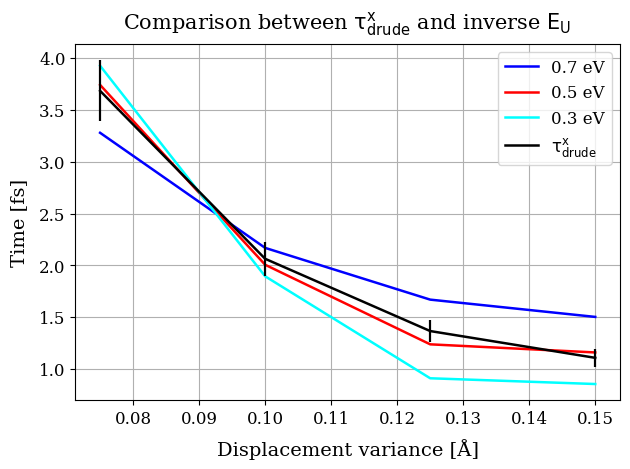

<Figure size 600x400 with 0 Axes>

In [83]:
tau_x_drude_arr_sigma=np.array([8.06247981, 5.88323652, 3.67338893, 2.05586172, 1.35875196,
       1.10176995, 0.61276261, 0.6973946 ])


amorph_disorders = [0.992, 0.976, 0.961, 0.95, 0.94, 0.93, 0.92]
sigma_disorders= [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

taus_arr = [np.float64(3.684136701758299),
 np.float64(2.0630999803000885),
 np.float64(1.3655561073550722),
 np.float64(1.107072091801164)]

parts_mean_eV=[]
parts_std_eV=[]

colors=['b', 'r', 'aqua']
num=0
for shift in [-0.7, -0.5, -0.3]:    
    
    # colors = blue_red_gradient(8)
    i=0
    
    lims_arr=[ [-0.18, -0.08],  [-0.15, -0.05], [-0.13, -0.03], []]
    
    urbach_arr=[]
    
    d2_zeros_analysis_arr=[]
    
    emin=1203
    emax=1455
    
    for j in range(8):
    
        if j>1 and j<6:
    
            dos_arr = []
    
            for main_folder in [folder1, folder3, folder5, folder7, folder9]:
                
    
                files_path = Path(main_folder) / "dos" / "data"
                filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
                df_temp = pd.read_csv(files_path / filenames_arr[j], comment='#')
                dos_arr.append(np.array(df_temp['dos']))
    
            dos_mean = np.mean(dos_arr, axis=0)
    
            # plt.plot(df_temp['energy'][emin:emax]-6.1, dos_mean[emin:emax],
            #          linewidth=1.2,
            #          label=extract_s_num(filenames_arr[j]),
            #          color=colors[i+1])
            # plt.yscale('log')
            i += 1
    
            res = fit_urbach_energy(df_temp['energy'][emin:emax]-6.1, dos_mean[emin:emax], Emin=shift+j*0.025, Emax=0+0.005*np.sqrt(j-1), log_base="e", make_plots=False)
            print("EU (eV) =", res["EU_eV"], "E_U std =", res["EU_std_eV"])


            print("parts results mean eV: ", res["EU_parts_from_mean_slope_eV"])
            print("parts results std eV: ", res["EU_parts_from_mean_slope_std_eV"])

            parts_mean_eV.append(res["EU_parts_from_mean_slope_eV"])
            parts_std_eV.append(res["EU_parts_from_mean_slope_std_eV"])
            
        #           "EU_parts_eV": EU_parts,
        # "EU_parts_mean_eV": EU_parts_mean,
        # "EU_parts_std_eV": EU_parts_std,
        # "EU_parts_info"
    
            # print("second_deriv_analysis: ", res["triples_E_d1_d2"])
    
            urbach_arr.append(res["EU_eV"])
    
    
    # plt.plot(tau_x_drude_main_folders[0][1:])
    plt.plot(sigma_disorders[2:6], l2_normalize(1/np.abs(np.array(urbach_arr)), np.array(taus_arr))[1], 
             label=str(-shift) + ' eV', color=colors[num], linewidth=1.8)
    print(l2_normalize(1/np.abs(np.array(urbach_arr)), np.array(tau_x_drude_main_folders[0][2:]))[0])
    num=num+1
    
plt.plot(sigma_disorders[2:6], taus_arr, label=r'$\mathrm{\tau}_{\mathrm{drude}}^{\mathrm{x}}$', color='black', linewidth=1.8)
plt.errorbar(sigma_disorders[2:6], taus_arr, yerr=0.08 * np.array(taus_arr), 
             fmt='none', color='black', elinewidth=1.58)


plt.title(r"Comparison between $\mathrm{\tau}_{\mathrm{drude}}^{\mathrm{x}}$ and inverse $\mathrm{E_U}$", fontsize=15, y=1.02)
plt.ylabel('Time [fs]', fontsize=14, labelpad=8)
plt.xlabel('Displacement variance [Å]', fontsize=14, labelpad=8)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()

plt.savefig("thesis_plots/cco/png/" + 'urbach_drude_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'urbach_drude_comparison.pdf', bbox_inches="tight")

plt.figure(figsize=(6, 4))

plt.show()
plt.close()

# ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[2], 'b', label='1.5 eV', linewidth=2)
# ax1.errorbar(
#     sigma_disorders[:6],
#     all_final_energy_z_vals[2],
#     yerr=0.035 * all_final_energy_z_vals[2],
#     fmt='none',
#     color='b', elinewidth=2
# )

In [22]:
# sigma_disorders[1:6]

In [23]:
# # для беспорядков от 0.05 до 0.15 (5 значений)
# # first deriv first minimum (2-ой холм)
# handmade_first_deriv_arr=[4.05, 3.03, 1/0.43, 2.2, 1.05]

# # first deriv first maximum (1-ый холм если идти справа налево)
# handmade_first_deriv_arr_v2=[1.05, 2.4, 1/0.43, 0.94, 0.9]

In [24]:
# plt.plot(tau_x_drude_main_folders[0][1:])
# plt.plot(l2_normalize(1/np.abs(np.array(urbach_arr)), np.array(tau_x_drude_main_folders[0][1:]))[1])

In [25]:
# tau_x_drude_main_folders[0]

## energy

### plots

In [26]:
# main_folders

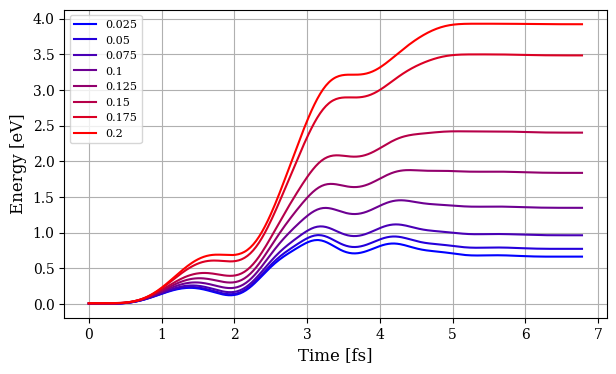

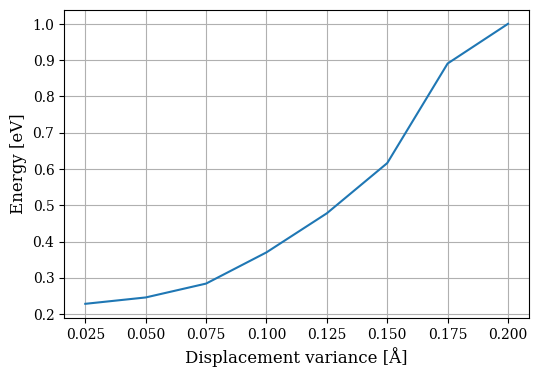

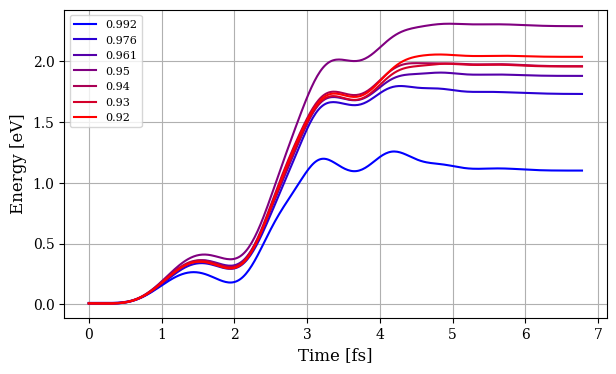

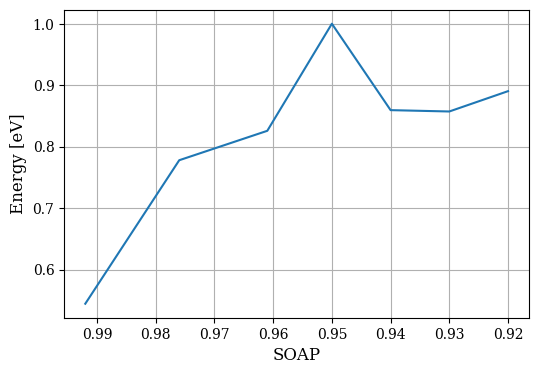

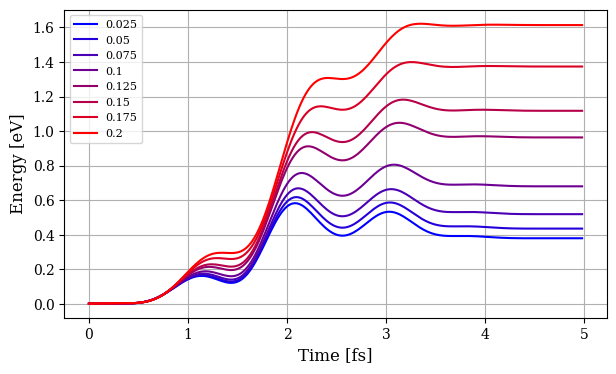

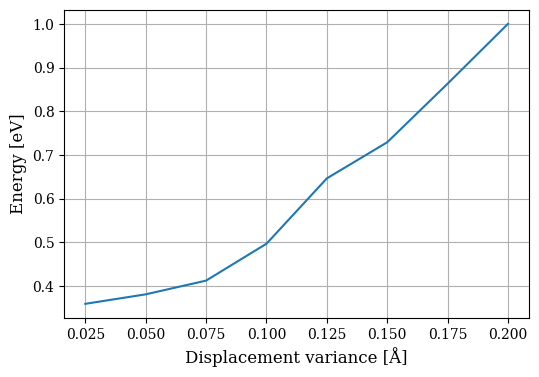

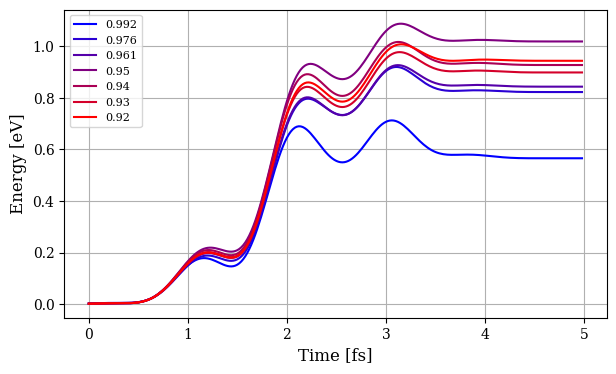

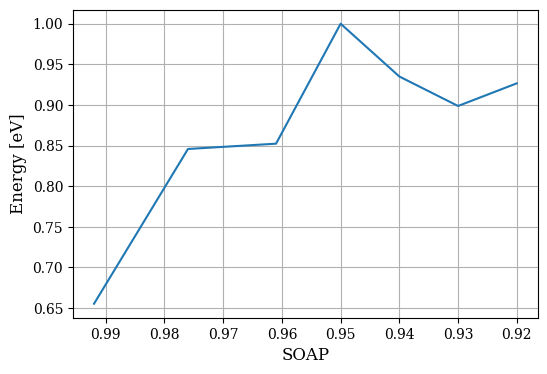

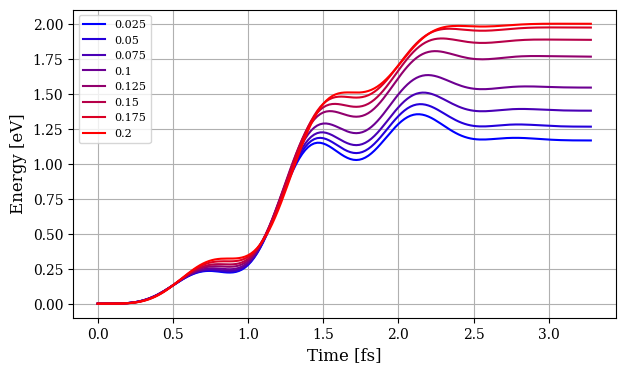

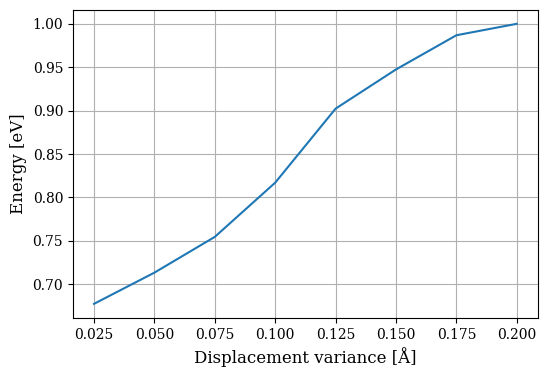

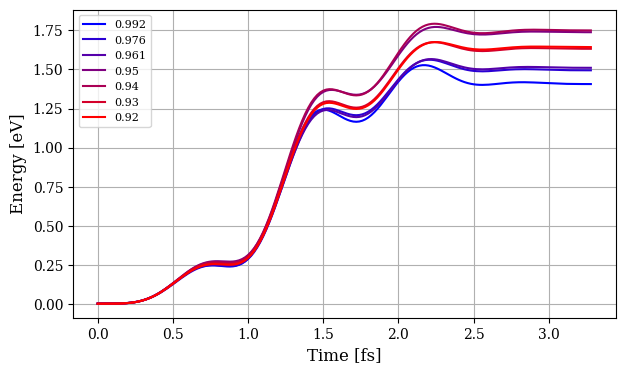

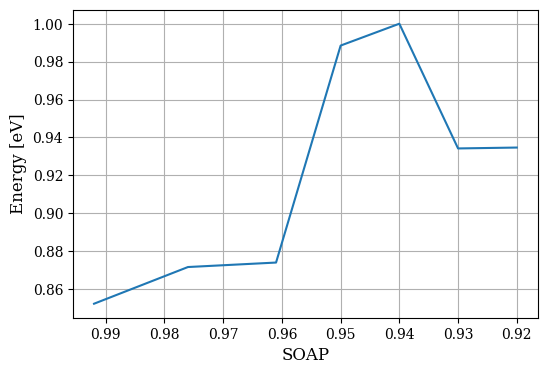

In [27]:
for main_folder in main_folders:
    if(main_folder):

        files_path = Path(main_folder+'/current_energy/data')
        filenames_arr=[]
        
        for item in files_path.iterdir():
            filename = Path(item).name
            # print(filename)
            filenames_arr.append(filename)
        
        filenames_arr = sorted(filenames_arr)

        if '1eV' in main_folder:
            t1, t2 = (385, 725)
        if '1.5eV' in main_folder:
            t1, t2 = (425, 675)
        if '2eV' in main_folder:
            t1, t2 = (460, 625)
        
        colors = blue_red_gradient(len(filenames_arr))

        plt.figure(figsize=(7, 4))
        plt.grid()
        plt.xlabel('Time [fs]', fontsize=12)
        plt.ylabel('Energy [eV]', fontsize=12)

        disorders=[]
        final_energies=[]
        j=0
        for f in filenames_arr:
            if 'amorphous' in f:
                label_name=extract_amorphous_value(f[:-4])
            else: label_name=extract_s_num(f[:-4])
            # print(extract_s_num(f))
            df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
            plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
            final_energies.append(max(df['En_both_z']))
            disorders.append(label_name)
            j=j+1
            
        plt.legend(fontsize=8)

        plt.figure(figsize=(6, 4))
        plt.plot(disorders, np.array(final_energies)/max(final_energies))
        if 'amorphous' in main_folder:
            plt.gca().invert_xaxis()
            plt.xlabel('SOAP', fontsize=12)
        else: plt.xlabel('Displacement variance [Å]', fontsize=12)
        plt.grid()
        plt.ylabel('Energy [eV]', fontsize=12)

In [28]:
max(final_energies)

1.79200307381637

### z

#### averaging error

In [29]:
amorph_disorders = [0.992, 0.976, 0.961, 0.95, 0.94, 0.93, 0.92]
sigma_disorders= [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

In [30]:
# plt.figure(figsize=(7, 4))
# plt.grid()

# all_mean_vals=[]

# for main_folder in [folder3, folder7]:

#     files_path = Path(main_folder+'/current_energy/data')
#     filenames_arr=[]
    
#     for item in files_path.iterdir():
#         filename = Path(item).name
#         # print(filename)
#         filenames_arr.append(filename)
    
#     filenames_arr = sorted(filenames_arr)

#     if '21fs' in main_folder:
#         t1, t2 = (425, 640)

#     if '12fs' in main_folder:
#         t1, t2 = (200, 415)
    
#     colors = blue_red_gradient(len(filenames_arr))
#     if not ('amorphous' in filenames_arr[0]):
#         colors=blue_red_gradient(6)

#     plt.xlabel('Time [fs]', fontsize=12)
#     plt.ylabel('Energy [eV]', fontsize=12)

#     disorders=[]
#     final_energies=[]
#     j=0
#     mean_vals=[]
#     for f in filenames_arr:

#         if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
#             if 'amorphous' in f:
#                 label_name=extract_amorphous_value(f[:-4])
#             else: label_name=extract_s_num(f[:-4])
#             # print(extract_s_num(f))
#             df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
#             if main_folder == folder3:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
#             else:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j])
#             final_energies.append(max(df['En_both_z']))
#             disorders.append(label_name)
#             j=j+1
#             mean_vals.append(np.mean(df['En_both_z'][t1:t2]))

#     all_mean_vals.append(mean_vals)


#     plt.legend(fontsize=9)

# # 1.5 eV pump 5d11 

In [31]:
# plt.plot(sigma_disorders[:6], abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1]))), color='b')
# plt.grid()
# print(np.mean(abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))
# print(np.std(abs(abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))

In [32]:
# plt.figure(figsize=(7, 4))
# plt.grid()

# all_mean_vals=[]

# for main_folder in [folder1, folder9]:

#     files_path = Path(main_folder+'/current_energy/data')
#     filenames_arr=[]
    
#     for item in files_path.iterdir():
#         filename = Path(item).name
#         # print(filename)
#         filenames_arr.append(filename)
    
#     filenames_arr = sorted(filenames_arr)

#     if '21fs' in main_folder:
#         t1, t2 = (415, 660)

#     if '12fs' in main_folder:
#         t1, t2 = (190, 435)
    
#     colors = blue_red_gradient(len(filenames_arr))
#     if not ('amorphous' in filenames_arr[0]):
#         colors=blue_red_gradient(6)

#     plt.xlabel('Time [fs]', fontsize=12)
#     plt.ylabel('Energy [eV]', fontsize=12)

#     disorders=[]
#     final_energies=[]
#     j=0
#     mean_vals=[]
#     for f in filenames_arr:

#         if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
#             if 'amorphous' in f:
#                 label_name=extract_amorphous_value(f[:-4])
#             else: label_name=extract_s_num(f[:-4])
#             # print(extract_s_num(f))
#             df = pd.read_csv(main_folder + "/current_energy/data/" + f, comment='#')
#             if main_folder == folder1:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j], label=label_name)
#             else:
#                 plt.plot(df['time'][t1:t2]-df['time'][t1], df['En_both_z'][t1:t2], color=colors[j])
#             final_energies.append(max(df['En_both_z']))
#             disorders.append(label_name)
#             j=j+1
#             mean_vals.append(np.mean(df['En_both_z'][t1:t2]))

#     all_mean_vals.append(mean_vals)
#     plt.legend(fontsize=9)

# # 1 eV pump 1d12 Jan28, Jan26

In [33]:
# plt.plot(sigma_disorders[:6], abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1]))), color='b')
# plt.grid()
# print(np.mean(abs(1-abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))
# print(np.std(abs(abs(np.array(all_mean_vals[0])/np.array(all_mean_vals[1])))))

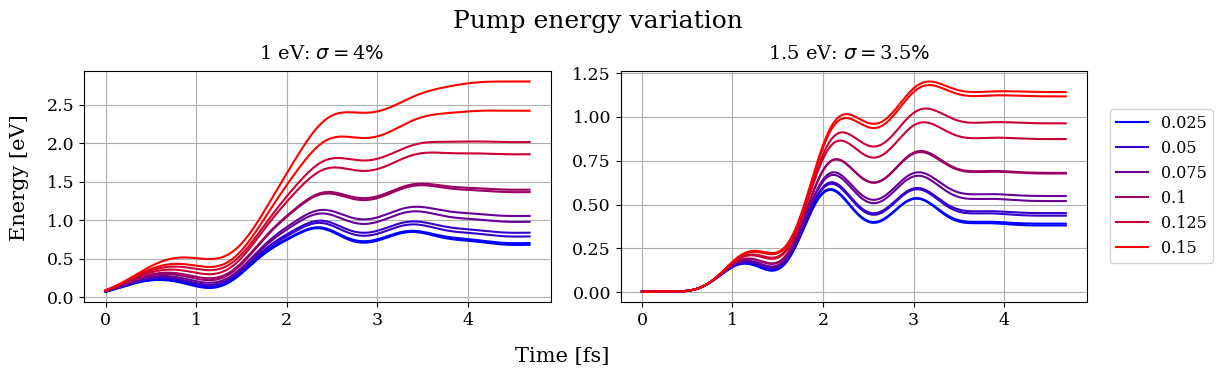

In [34]:
figsize = (12, 4)

tick_size = 12.5
axis_label_size = 15
suptitle_size = 18
legend_fontsize = 11.5
col_title_size = 14

suptitle_text = "Pump energy variation"

fig, axes = plt.subplots(1, 2, figsize=figsize)


groups = [
    [folder1, folder9],
    [folder3, folder7]
]

for ax, folder_group in zip(axes, groups):

    ax.grid()
    ax.tick_params(labelsize=tick_size)

    for main_folder in folder_group:

        files_path = Path(main_folder) / 'current_energy' / 'data'
        filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

        if '21fs' in main_folder:
            t1, t2 = (425, 660)
        if '12fs' in main_folder:
            t1, t2 = (200, 435)

        colors = blue_red_gradient(len(filenames_arr))
        if not ('amorphous' in filenames_arr[0]):
            colors=blue_red_gradient(6)

        
        for j, f in enumerate(filenames_arr):

            if 'amorphous' in f:
                label_name = extract_amorphous_value(f[:-4])
            else:
                label_name = extract_s_num(f[:-4])

            df = pd.read_csv(files_path / f, comment='#')

            if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
                ax.plot(
                    df['time'][t1:t2] - df['time'][t1],
                    df['En_both_z'][t1:t2],
                    color=colors[j],
                    label=label_name if main_folder == folder_group[0] else None
                )

# ---------- Общая легенда справа ----------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(0.92, 0.48),
    fontsize=legend_fontsize,
    frameon=True
)

# ---------- ЕДИНЫЕ подписи ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.03, x=0.47)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, y=0.92)


# Оставляем место справа и сверху
plt.tight_layout(rect=(0, 0, 0.92, 0.90))

# ---------- Подписи над столбцами ----------
col_titles = [r"1 eV: $\sigma$$=$4$\%$", r"1.5 eV: $\sigma$$=$3.5$\%$"]

fig.canvas.draw()  # теперь AFTER tight_layout

for ax, title in zip(axes, col_titles):
    bbox = ax.get_position()
    x_center = bbox.x0 + bbox.width / 2
    y_top = bbox.y1 + 0.02   # можно чуть подвинуть

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=col_title_size
    )

fig.subplots_adjust(wspace=0.15)

plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_variation.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_variation.pdf', bbox_inches="tight")

plt.show()
plt.close()

In [35]:
# для 8 точек
# для 1 эВ -- std -- 6%
# для 1.5 эВ -- std -- 3.5%
# для 2 эВ -- std -- 2% (допустим)

# для 6 точек
# для 1 эВ -- std -- 3.5%
# для 1.5 эВ -- std -- 3.5%
# для 2 эВ -- std -- 2% (допустим)

#### full

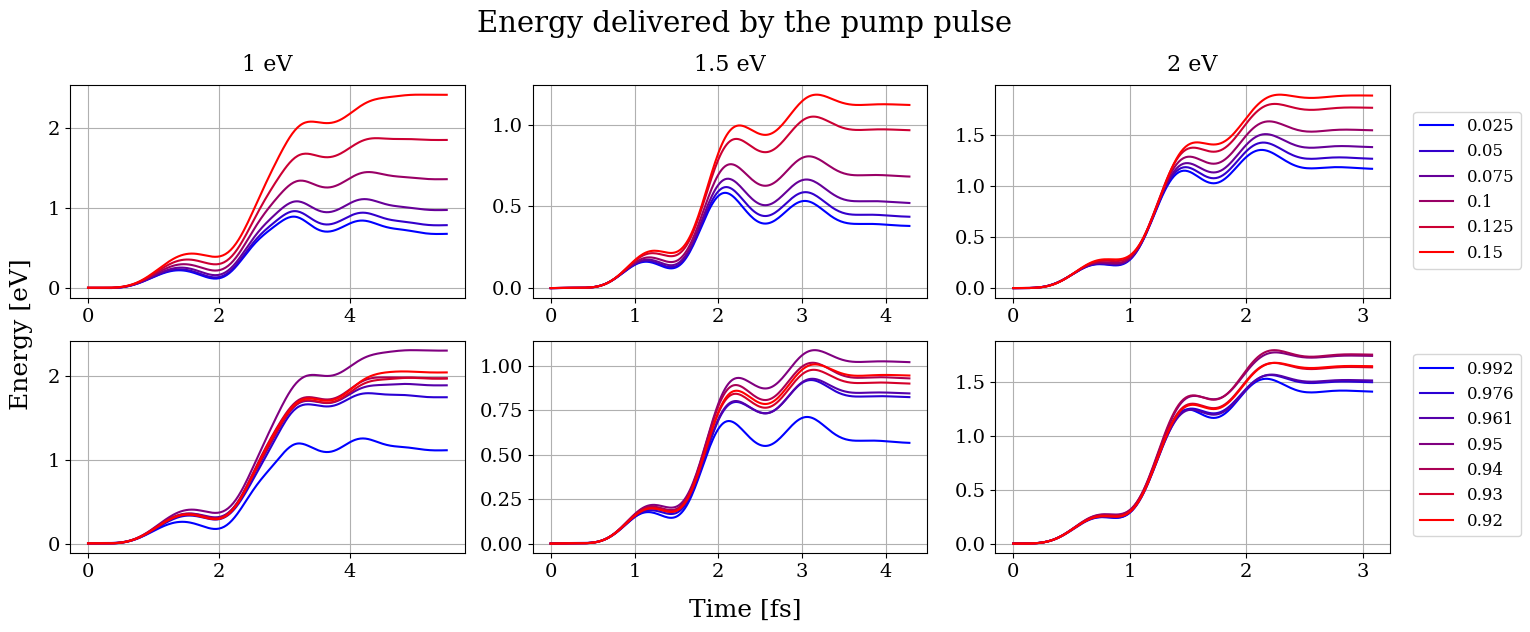

In [36]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Energy delivered by the pump pulse'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (385, 660)
    if '1.5eV' in main_folder:
        t1, t2 = (425, 640)
    if '2eV' in main_folder:
        t1, t2 = (460, 615)
        
    if '12fs' in main_folder:
        t1, t2 = (200, 415)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
        
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_both_z'][t1:t2],
                color=colors[j],
                label=label_name
            )

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_comparison_pump_pulse.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_comparison_pump_pulse.pdf', bbox_inches="tight")

plt.show()
plt.close()

#### final vals

In [37]:
amorph_disorders = [0.992, 0.976, 0.961, 0.95, 0.94, 0.93, 0.92]
sigma_disorders= [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

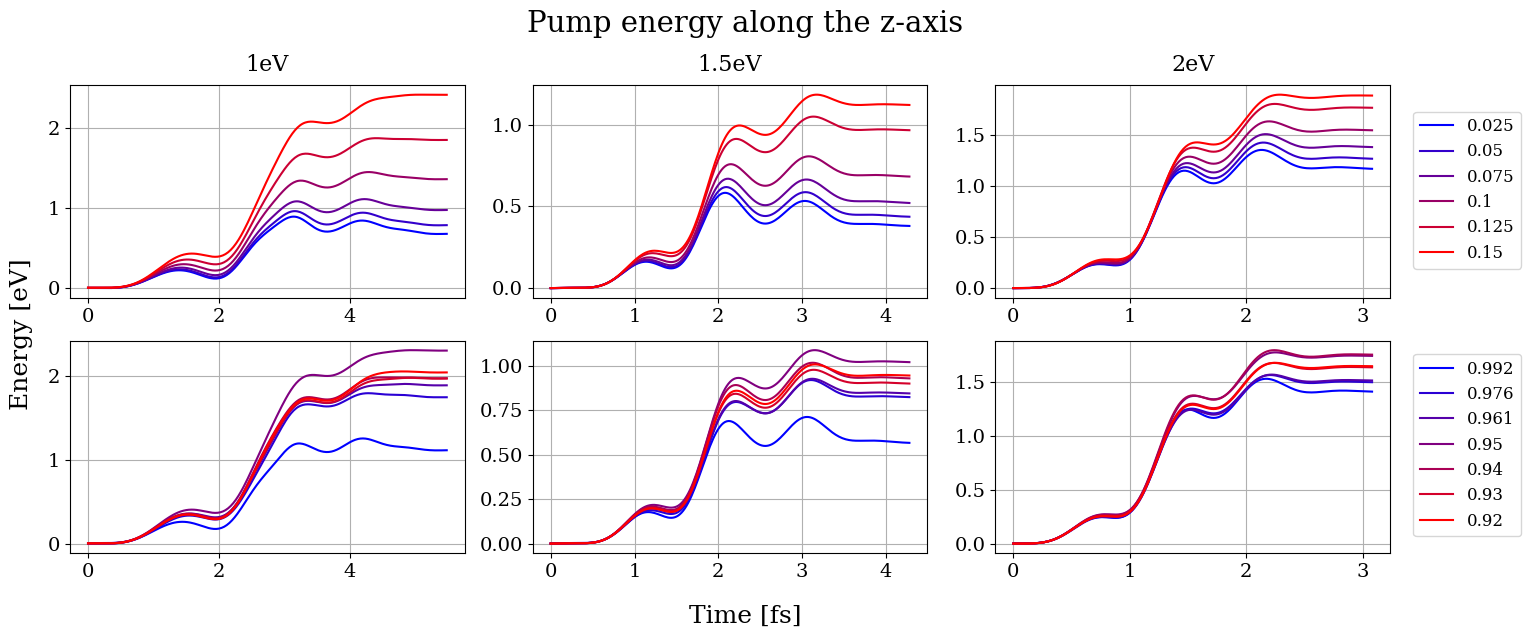

In [38]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Pump energy along the z-axis'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

all_final_energy_z_vals=[]

disorders_sigma=[]
disorders_amorphous=[]

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (385, 660)
    if '1.5eV' in main_folder:
        t1, t2 = (425, 640)
    if '2eV' in main_folder:
        t1, t2 = (460, 615)
        
    if '12fs' in main_folder:
        t1, t2 = (200, 415)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    
    final_energy_z_vals=[]
    for j, f in enumerate(filenames_arr):
    
        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            final_energy_z_vals.append(np.array(df['En_both_z'])[-1])
            if 'amorphous' in f:
                disorders_amorphous.append(label_name)
            else: 
                disorders_sigma.append(label_name)
            
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_both_z'][t1:t2],
                color=colors[j],
                label=label_name, linewidth=1.5
            )

    ax.tick_params(labelsize=tick_size)
    # print(main_folder)
    # print(np.round(final_energy_z_vals, 2))
    all_final_energy_z_vals.append(final_energy_z_vals/max(final_energy_z_vals))

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1eV', '1.5eV', '2eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

# plt.savefig("thesis_plots/energy/z/png/" + 'pump_energy_comparison_pump_pulse.png', dpi=200, bbox_inches="tight")
# plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_energy_comparison_pump_pulse.pdf', bbox_inches="tight")
plt.show()
plt.close()

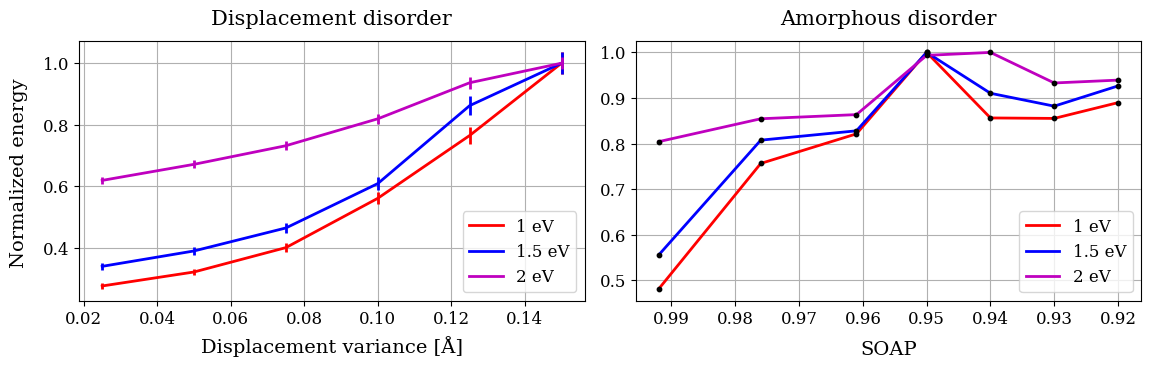

In [39]:

# =======================
# Размеры шрифтов
# =======================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12
column_title_fontsize = 15
suptitle_fontsize = 16

# =======================
# Subplots
# =======================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

# =======================
# Первый график
# =======================

ax1.set_xlabel('Displacement variance [Å]', fontsize=label_fontsize, labelpad=6)
ax1.grid()
ax1.set_title('Displacement disorder', fontsize=column_title_fontsize, y=1.03)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[0], 'r', label='1 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[0],
    yerr=0.035 * all_final_energy_z_vals[0],
    fmt='none',
    color='r', elinewidth=2
)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[2], 'b', label='1.5 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[2],
    yerr=0.035 * all_final_energy_z_vals[2],
    fmt='none',
    color='b', elinewidth=2
)

ax1.plot(sigma_disorders[:6], all_final_energy_z_vals[4], 'm', label='2 eV', linewidth=2)
ax1.errorbar(
    sigma_disorders[:6],
    all_final_energy_z_vals[4],
    yerr=0.02 * all_final_energy_z_vals[4],
    fmt='none',
    color='m', elinewidth=2
)

ax1.legend(fontsize=legend_fontsize, loc='lower right')


# =======================
# Второй график
# =======================

ax2.set_xlabel('SOAP', fontsize=label_fontsize, labelpad=9)
ax2.grid()
ax2.set_title('Amorphous disorder', fontsize=column_title_fontsize, y=1.03)
ax2.invert_xaxis()

ax2.plot(amorph_disorders, all_final_energy_z_vals[1], 'r', label='1 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[1], color='black', s=10, zorder=3)

ax2.plot(amorph_disorders, all_final_energy_z_vals[3], 'b', label='1.5 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[3], color='black', s=10, zorder=3)

ax2.plot(amorph_disorders, all_final_energy_z_vals[5], 'm', label='2 eV', linewidth=2)
ax2.scatter(amorph_disorders, all_final_energy_z_vals[5], color='black', s=10, zorder=3)

ax2.legend(fontsize=legend_fontsize, loc='lower right')


# =======================
# ОДНА подпись Y на всю фигуру
# =======================

fig.text(
    0.045, 0.5,
    'Normalized energy',
    va='center',
    rotation='vertical',
    fontsize=label_fontsize
)

# =======================
# Общий заголовок
# =======================

# fig.suptitle(
#     'Pump Energy vs Disorder Metrics',
#     fontsize=suptitle_fontsize
# )

# =======================
# Размеры тиков
# =======================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

plt.tight_layout(rect=[0.06, 0, 1, 0.95])  # чтобы не обрезалось


plt.savefig("thesis_plots/energy/z/png/" + 'pump_pulse_photoinjection_energy_final_vals.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/z/pdf/" + 'pump_pulse_photoinjection_energy_final_vals.pdf', bbox_inches="tight")

plt.show()
plt.close()

### x

In [40]:
energy_x_folders = [folder5, folder6, folder7, folder8]

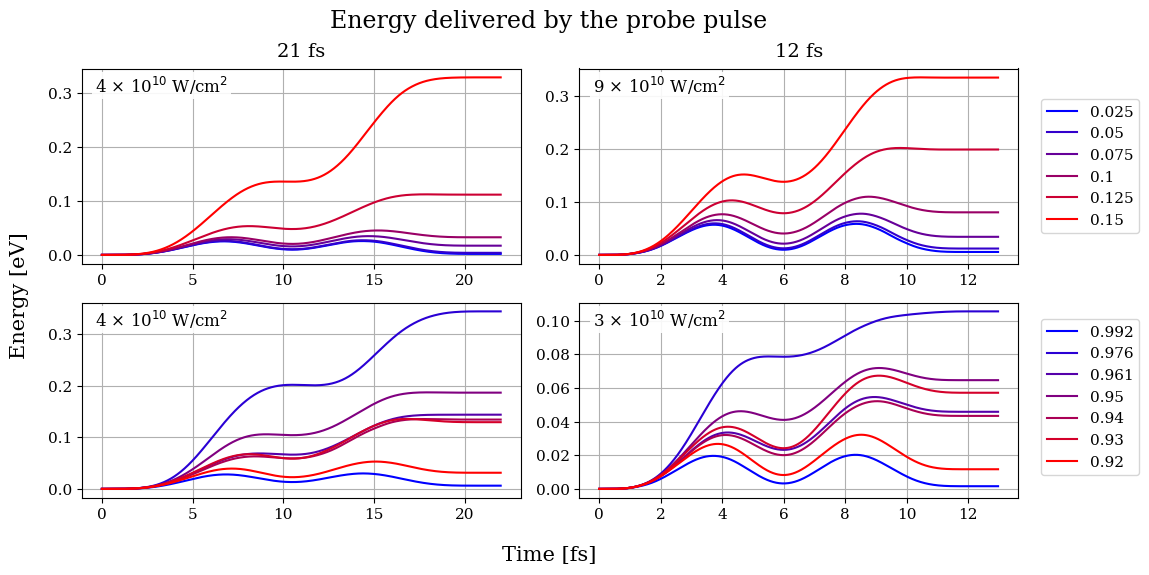

In [41]:
energy_x_folders = [folder5, folder6, folder7, folder8]

# ================= НАСТРОЙКИ =================
figsize = (11, 5.5)

# размеры текста
col_title_size = 14
axis_label_size = 15
tick_size = 11
suptitle_size = 17

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Energy delivered by the probe pulse'
suptitle_x = 0.5
suptitle_y = 1.02

# легенды справа (по одной на строку)
legend_fontsize = 11
legend_x = 0.94
legend_y_top = 0.735
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 2, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(energy_x_folders):

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '12fs' in main_folder:
        t1, t2 = (0, 650)
    if '21fs' in main_folder:
        t1, t2 = (0, 1100)


    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['En_probe_x'][t1:t2],
                color=colors[j],
                label=label_name
            )

    # print(extract_p(f))



    # --- подпись I0 в левом верхнем углу текущей оси ---
    I0 = extract_p(f)  # f здесь = последний файл из filenames_arr

    # экспоненциальная форма: value * 10^{power}, value с точностью до 0 знаков

    power = int(np.floor(np.log10(abs(I0))))
    value = I0 / (10 ** power)
    value = int(np.round(value))  # 0 знаков после запятой

    # на всякий случай нормализация, если округление дало 10
    if abs(value) == 10:
        value = int(np.sign(value) * 1)
        power += 1

    # text = rf"I$_{{\mathrm{{peak}}}}$ = {value} × 10$^{{{power}}}$ W/cm$^2$"
    text = rf"{value} × 10$^{{{power}}}$ W/cm$^2$"

    ax.text(
        0.03, 0.97, text,
        transform=ax.transAxes,   # координаты внутри оси: (0..1, 0..1)
        ha='left', va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2.0)
    )
    

    

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа



# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size)
fig.supylabel('Energy [eV]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['21 fs', '12 fs']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/energy/x/png/" + 'pump_energy_comparison_probe_pulse.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/energy/x/pdf/" + 'pump_energy_comparison_probe_pulse.pdf', bbox_inches="tight")

plt.show()
plt.close()

## current

### z

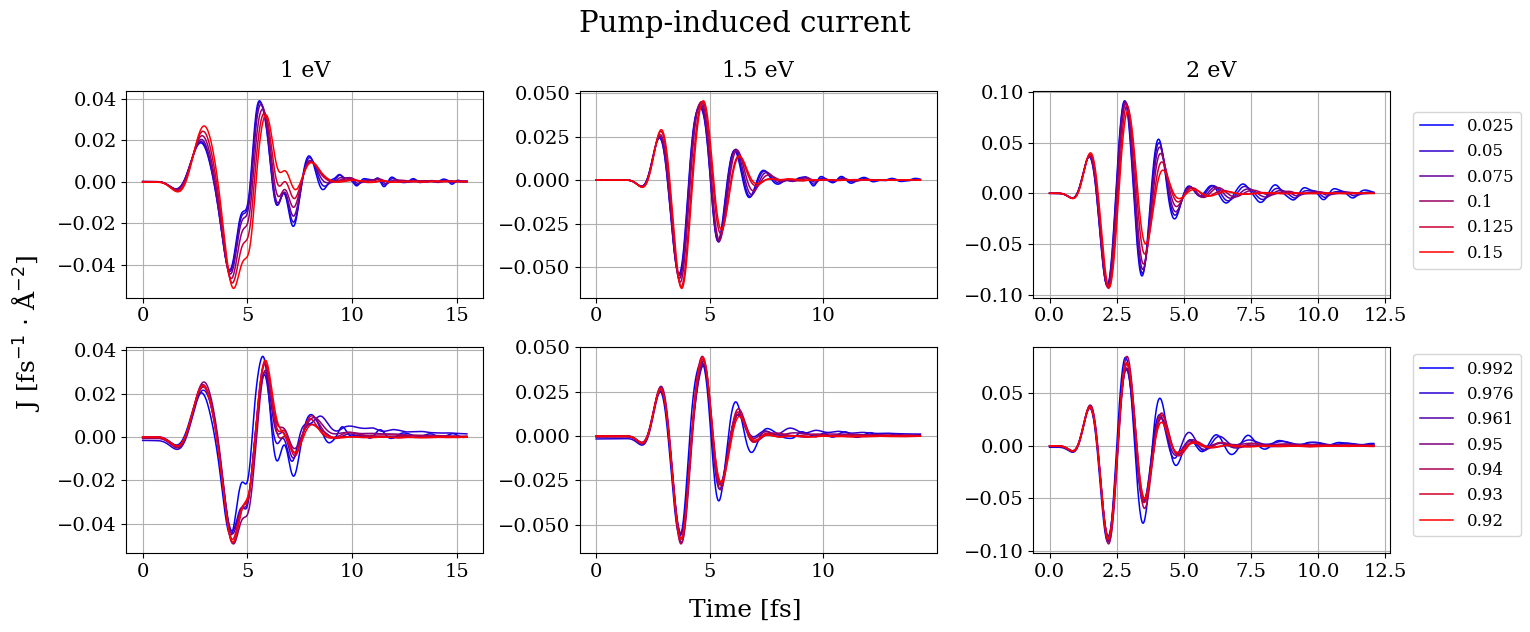

In [42]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Pump-induced current'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            ax.plot(
                df['time'][t1:t2]-df['time'][t1],
                df['Jm_both_z'][t1:t2],
                color=colors[j],
                label=label_name, linewidth=1.1
            )

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('J [fs$^{-1}$ $\\cdot$ Å$^{-2}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/current/z/png/" + 'pump_pulse_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/current/z/pdf/" + 'pump_pulse_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

### x

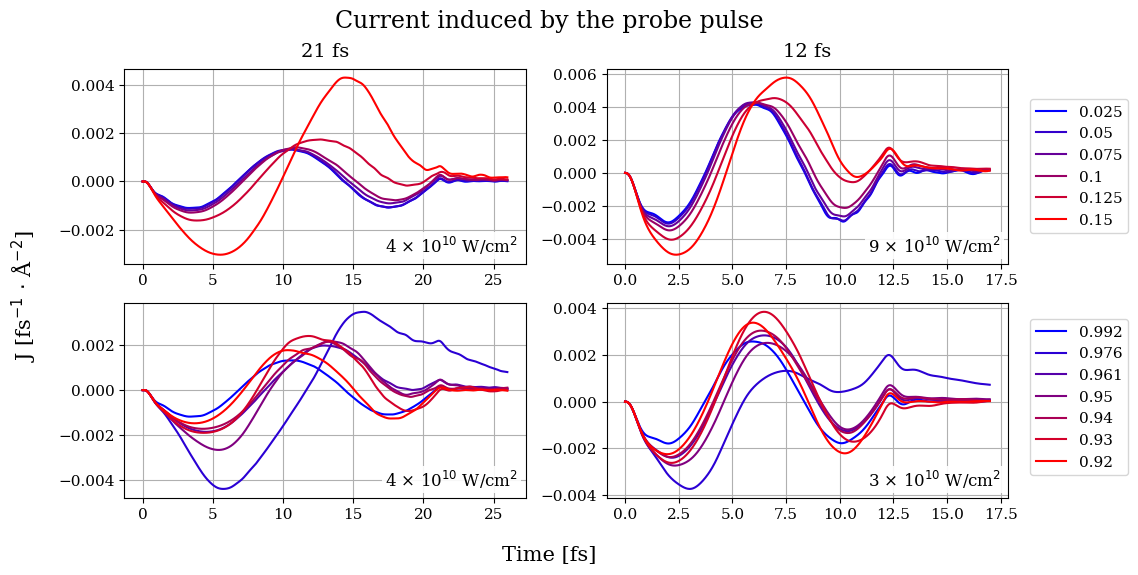

In [43]:
energy_x_folders = [folder5, folder6, folder7, folder8]

# ================= НАСТРОЙКИ =================
figsize = (11, 5.5)

# размеры текста
col_title_size = 14
axis_label_size = 15
tick_size = 11
suptitle_size = 17

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Current induced by the probe pulse'
suptitle_x = 0.5
suptitle_y = 1.02

# легенды справа (по одной на строку)
legend_fontsize = 11
legend_x = 0.93
legend_y_top = 0.735
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 2, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(energy_x_folders):

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '12fs' in main_folder:
        t1, t2 = (0, 850)
    if '21fs' in main_folder:
        t1, t2 = (0, 1300)


    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')
    
            ax.plot(
                df['time'][t1:t2] - df['time'][t1],
                df['Jm_probe_x'][t1:t2],
                color=colors[j],
                label=label_name
            )

    # print(extract_p(f))



    # --- подпись I0 в левом верхнем углу текущей оси ---
    I0 = extract_p(f)  # f здесь = последний файл из filenames_arr

    # экспоненциальная форма: value * 10^{power}, value с точностью до 0 знаков

    power = int(np.floor(np.log10(abs(I0))))
    value = I0 / (10 ** power)
    value = int(np.round(value))  # 0 знаков после запятой

    # на всякий случай нормализация, если округление дало 10
    if abs(value) == 10:
        value = int(np.sign(value) * 1)
        power += 1

    # text = rf"I$_{{\mathrm{{peak}}}}$ = {value} × 10$^{{{power}}}$ W/cm$^2$"
    text = rf"{value} × 10$^{{{power}}}$ W/cm$^2$"

    ax.text(
        0.65, 0.15, text,
        transform=ax.transAxes,   # координаты внутри оси: (0..1, 0..1)
        ha='left', va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2.0)
    )
    

    

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа



# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size)
fig.supylabel('J [fs$^{-1}$ $\\cdot$ Å$^{-2}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['21 fs', '12 fs']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/current/x/png/" + 'probe_pulse_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/current/x/pdf/" + 'probe_pulse_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

## hhg

### z

In [44]:
main_folder=main_folders[0]

files_path = Path(main_folder) / "hhg" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

filenames_arr = [f for f in filenames_arr if 'pump_pulse' in f]

files_path = Path(main_folder) / "hhg" / "data"

df = pd.read_csv(files_path / filenames_arr[0], comment='#')

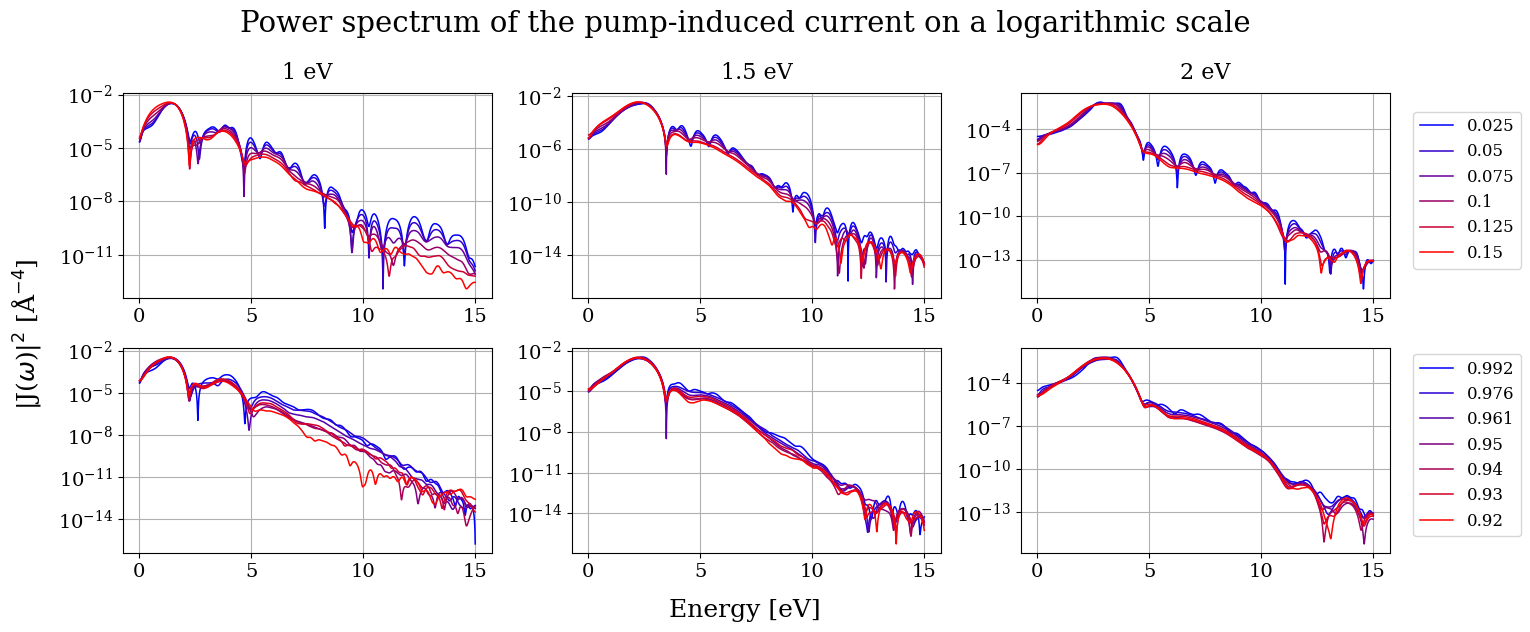

In [45]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Power spectrum of the pump-induced current on a logarithmic scale'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        continue
        # main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "hhg" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'pump_pulse' in f]

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            ax.plot(
                df['Energy_eV'][:1500],
                df['Abs2_Jm_z'][:1500],
                color=colors[j],
                label=label_name, linewidth=1.1
            )
        ax.set_yscale('log')

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Energy [eV]', fontsize=axis_label_size, y=0.02)
fig.supylabel(r'|J($\omega$)|$^2$ [Å$^{-4}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/hhg/z/png/" + 'hhg_pump_pulse_response_comparison_log.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/z/pdf/" + 'hhg_pump_pulse_response_comparison_log.pdf', bbox_inches="tight")

plt.show()
plt.close()

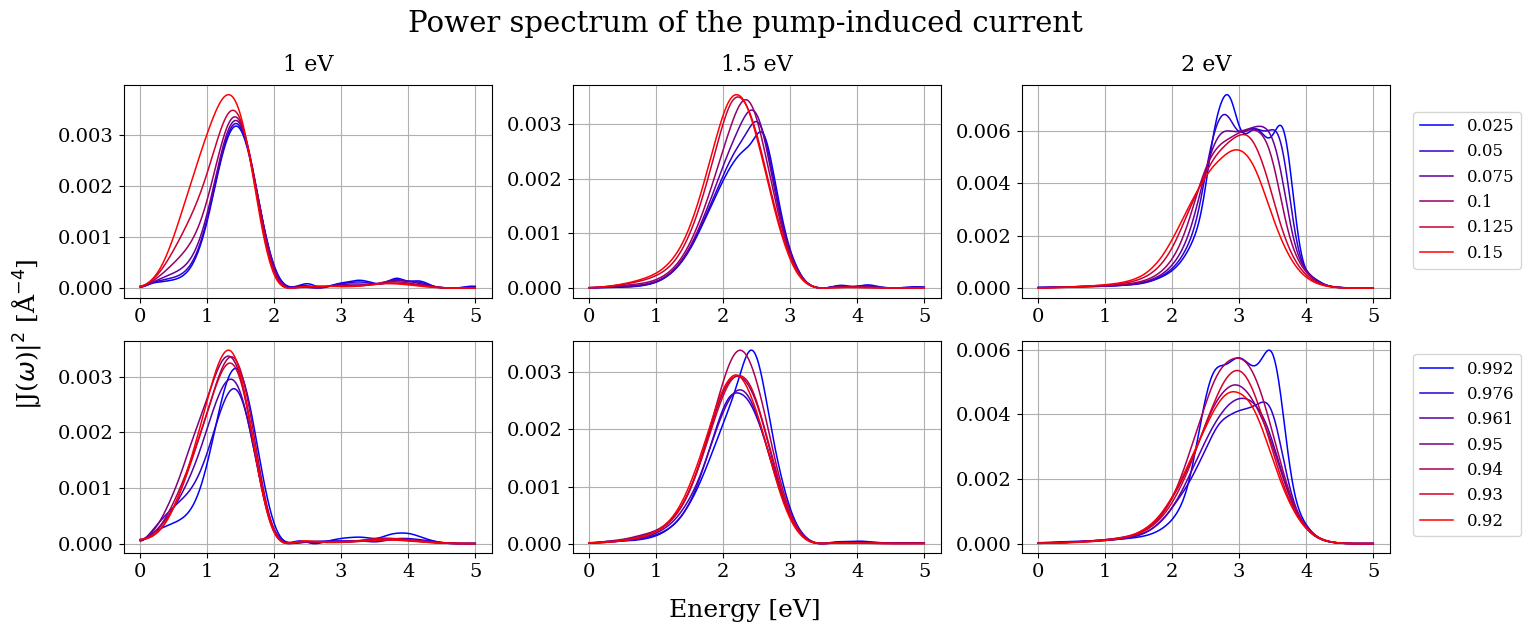

In [46]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Power spectrum of the pump-induced current'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        continue
        # main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "hhg" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'pump_pulse' in f]

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            ax.plot(
                df['Energy_eV'][:500],
                df['Abs2_Jm_z'][:500],
                color=colors[j],
                label=label_name, linewidth=1.1
            )
        # ax.set_yscale('log')

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Energy [eV]', fontsize=axis_label_size, y=0.02)
fig.supylabel(r'|J($\omega$)|$^2$ [Å$^{-4}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/hhg/z/png/" + 'hhg_pump_pulse_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/z/pdf/" + 'hhg_pump_pulse_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

### x

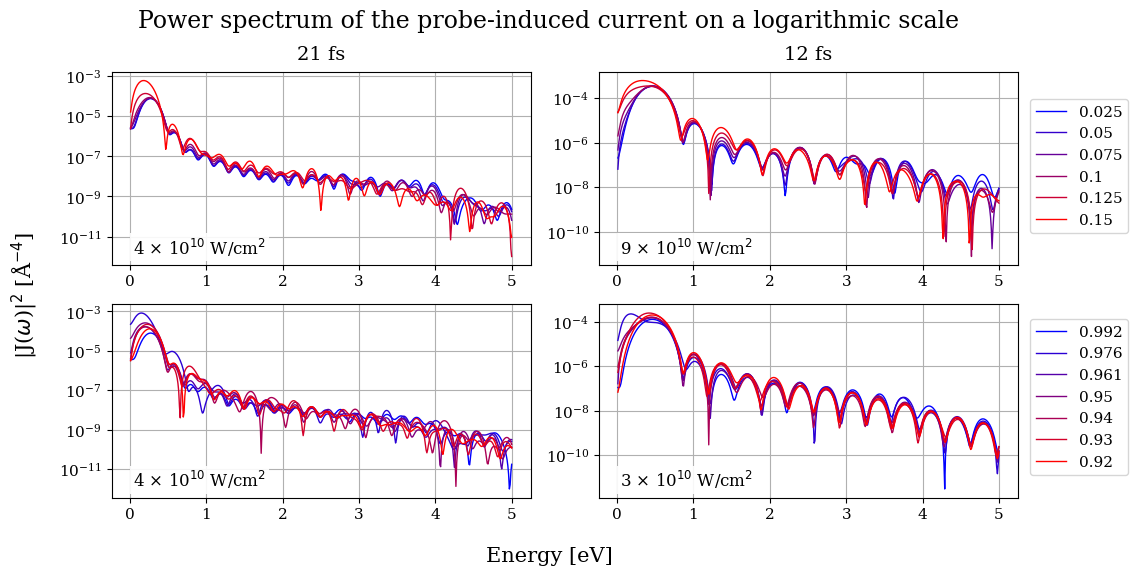

In [47]:
energy_x_folders = [folder5, folder6, folder7, folder8]

# ================= НАСТРОЙКИ =================
figsize = (11, 5.5)

# размеры текста
col_title_size = 14
axis_label_size = 15
tick_size = 11
suptitle_size = 17

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Power spectrum of the probe-induced current on a logarithmic scale'
suptitle_x = 0.5
suptitle_y = 1.02

# легенды справа (по одной на строку)
legend_fontsize = 11
legend_x = 0.93
legend_y_top = 0.735
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 2, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(energy_x_folders):

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "hhg" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'probe_pulse' in f]

    if '12fs' in main_folder:
        t1, t2 = (0, 850)
    if '21fs' in main_folder:
        t1, t2 = (0, 1300)


    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if ('amorphous' in f) or (extract_s_num(f[20:-4])<0.16):
            
            label_name = extract_amorphous_value(f[20:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')

            ax.plot(
                df['Energy_eV'][:500],
                df['Abs2_Jm_x'][:500],
                color=colors[j],
                label=label_name, linewidth=1
            )
            ax.set_yscale('log')

    # print(extract_p(f))



    # --- подпись I0 в левом верхнем углу текущей оси ---
    I0 = extract_p(f[20:-4])  # f здесь = последний файл из filenames_arr

    # экспоненциальная форма: value * 10^{power}, value с точностью до 0 знаков

    power = int(np.floor(np.log10(abs(I0))))
    value = I0 / (10 ** power)
    value = int(np.round(value))  # 0 знаков после запятой

    # на всякий случай нормализация, если округление дало 10
    if abs(value) == 10:
        value = int(np.sign(value) * 1)
        power += 1

    # text = rf"I$_{{\mathrm{{peak}}}}$ = {value} × 10$^{{{power}}}$ W/cm$^2$"
    text = rf"{value} × 10$^{{{power}}}$ W/cm$^2$"

    ax.text(
        0.05, 0.15, text,
        transform=ax.transAxes,   # координаты внутри оси: (0..1, 0..1)
        ha='left', va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2.0)
    )
    

    

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа



# ---------- Общие подписи осей ----------
fig.supxlabel('Energy [eV]', fontsize=axis_label_size)
fig.supylabel(r'|J($\omega$)|$^2$ [Å$^{-4}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['21 fs', '12 fs']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/hhg/x/png/" + 'hhg_probe_pulse_response_comparison_log_scale.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/x/pdf/" + 'hhg_probe_pulse_response_comparison_log_scale.pdf', bbox_inches="tight")

plt.show()
plt.close()

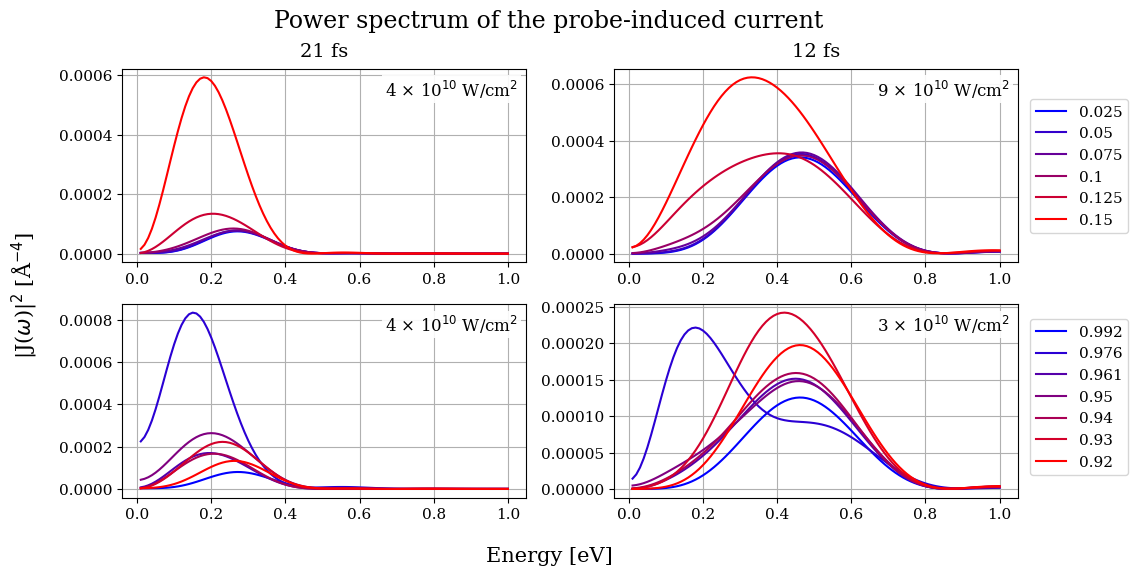

In [48]:
energy_x_folders = [folder5, folder6, folder7, folder8]

# ================= НАСТРОЙКИ =================
figsize = (11, 5.5)

# размеры текста
col_title_size = 14
axis_label_size = 15
tick_size = 11
suptitle_size = 17

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Power spectrum of the probe-induced current'
suptitle_x = 0.5
suptitle_y = 1.02

# легенды справа (по одной на строку)
legend_fontsize = 11
legend_x = 0.93
legend_y_top = 0.735
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 2, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(energy_x_folders):

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "hhg" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'probe_pulse' in f]

    if '12fs' in main_folder:
        t1, t2 = (0, 850)
    if '21fs' in main_folder:
        t1, t2 = (0, 1300)


    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if ('amorphous' in f) or (extract_s_num(f[20:-4])<0.16):
            
            label_name = extract_amorphous_value(f[20:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
            df = pd.read_csv(files_path / f, comment='#')

            ax.plot(
                df['Energy_eV'][:100],
                df['Abs2_Jm_x'][:100],
                color=colors[j],
                label=label_name
            )
            # ax.set_yscale('log')

    # print(extract_p(f))



    # --- подпись I0 в левом верхнем углу текущей оси ---
    I0 = extract_p(f[20:-4])  # f здесь = последний файл из filenames_arr

    # экспоненциальная форма: value * 10^{power}, value с точностью до 0 знаков

    power = int(np.floor(np.log10(abs(I0))))
    value = I0 / (10 ** power)
    value = int(np.round(value))  # 0 знаков после запятой

    # на всякий случай нормализация, если округление дало 10
    if abs(value) == 10:
        value = int(np.sign(value) * 1)
        power += 1

    # text = rf"I$_{{\mathrm{{peak}}}}$ = {value} × 10$^{{{power}}}$ W/cm$^2$"
    text = rf"{value} × 10$^{{{power}}}$ W/cm$^2$"

    ax.text(
        0.65, 0.95, text,
        transform=ax.transAxes,   # координаты внутри оси: (0..1, 0..1)
        ha='left', va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2.0)
    )
    

    

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа



# ---------- Общие подписи осей ----------
fig.supxlabel('Energy [eV]', fontsize=axis_label_size)
fig.supylabel(r'|J($\omega$)|$^{2}$ [Å$^{-4}$]', fontsize=axis_label_size, x=0.01)


# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['21 fs', '12 fs']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/hhg/x/png/" + 'hhg_probe_pulse_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/x/pdf/" + 'hhg_probe_pulse_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

### pulses spectrum

In [49]:
def fft_to_eV(dt_fs, s, remove_mean=True, window='hann',
              power=True, pad_factor=1):
    """
    dt_fs : шаг по времени в fs
    s     : сигнал
    pad_factor : во сколько раз увеличить длину (1 = без padding)
    """

    s = np.asarray(s)
    dt_s = dt_fs * 1e-15

    # --- предобработка ---
    x = s.astype(float).copy()
    if remove_mean:
        x -= x.mean()

    # --- окно ---
    if window is None:
        w = np.ones_like(x)
    else:
        window = window.lower()
        if window == 'hann':
            w = np.hanning(len(x))
        elif window == 'hamming':
            w = np.hamming(len(x))
        elif window == 'blackman':
            w = np.blackman(len(x))
        else:
            raise ValueError("window должен быть None/'hann'/'hamming'/'blackman'")

    xw = x * w

    # --- zero padding ---
    N = len(xw)
    N_pad = int(pad_factor * N)

    if pad_factor > 1:
        xw = np.pad(xw, (0, N_pad - N))

    # --- FFT ---
    S = np.fft.rfft(xw)
    f_hz = np.fft.rfftfreq(len(xw), d=dt_s)

    # --- перевод в eV ---
    h_eVs = 4.135667696e-15
    E_eV = h_eVs * f_hz

    amp = np.abs(S)
    spec = amp**2 if power else amp

    return E_eV, spec

In [50]:
main_folder=main_folders[0]

files_path = Path(main_folder) / "current_energy" / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

# filenames_arr = [f for f in filenames_arr if 'pump_pulse' in f]

files_path = Path(main_folder) / "current_energy" / "data"

df = pd.read_csv(files_path / filenames_arr[0], comment='#')

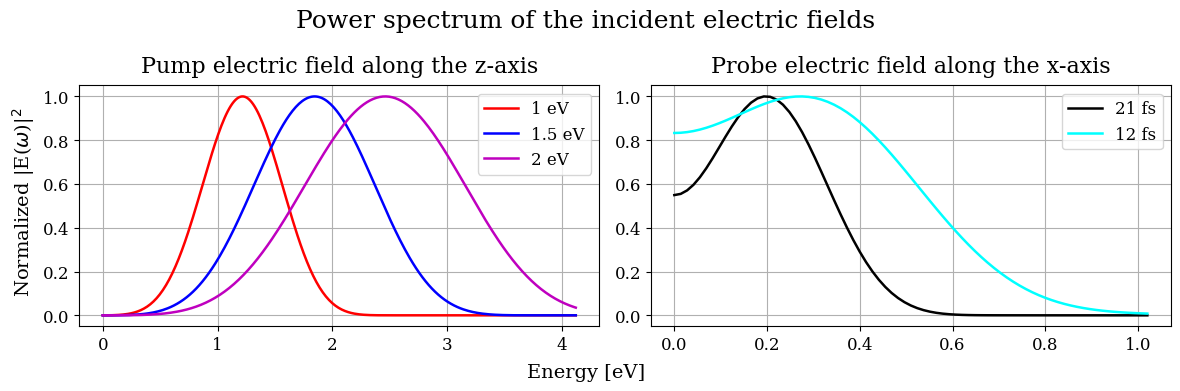

In [51]:

# ===============================
# Настройки размеров шрифтов
# ===============================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12
title_fontsize = 16
suptitle_fontsize = 18

# ===============================
# Создание figure
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

# ===============================
# Первый график (pump z)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals1=[]
j=0
for main_folder in [folder1, folder3, folder5]:

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')

    E_eV, spec = fft_to_eV(
        0.02,
        df['El_f_pump_z'],
        window='blackman',
        power=True,
        pad_factor=10
    )

    ax1.plot(E_eV[:300], spec[:300] / max(spec),
             linewidth=1.8, color=colors[j], label=labels[j])
    j=j+1
    max_vals1.append(E_eV[np.argmax(spec)])

ax1.set_title('Pump electric field along the z-axis', fontsize=title_fontsize, y=1.02)
ax1.grid(True)
ax1.legend(fontsize=legend_fontsize)


# ===============================
# Второй график (probe x)
# ===============================
colors=['black', 'aqua']
labels=['21 fs', '12 fs']
max_vals2=[]
j=0
for main_folder in [folder5, folder7]:

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')

    E_eV, spec = fft_to_eV(
        0.02,
        df['El_f_probe_x'],
        window='blackman',
        power=True,
        pad_factor=10
    )

    ax2.plot(E_eV[:75], spec[:75] / max(spec),
             linewidth=1.8, color=colors[j], label=labels[j])
    j=j+1
    max_vals2.append(E_eV[np.argmax(spec)])

ax2.set_title('Probe electric field along the x-axis', fontsize=title_fontsize, y=1.02)
ax2.grid(True)
ax2.legend(fontsize=legend_fontsize)


# ===============================
# Общие подписи осей
# ===============================

fig.supxlabel('Energy [eV]', fontsize=label_fontsize, y=0.05)
fig.supylabel(r'Normalized |E($\omega$)|$^{{2}}$', fontsize=label_fontsize)

# ===============================
# Общий заголовок
# ===============================

fig.suptitle('Power spectrum of the incident electric fields',
             fontsize=suptitle_fontsize, y=0.98)

# ===============================
# Размеры тиков
# ===============================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

# ===============================
# Отступы
# ===============================

plt.tight_layout()


plt.savefig("thesis_plots/hhg/" + 'pulses_power_spectrum_1.213_1.847_2.468_0.193_0.276.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/" + 'pulses_power_spectrum_1.213_1.847_2.468_0.193_0.276.pdf', bbox_inches="tight")

plt.show()
plt.close()

In [52]:
max_vals1

[np.float64(1.2131291908266666),
 np.float64(1.8472649042133333),
 np.float64(2.467615058613333)]

In [53]:
max_vals2

[np.float64(0.19299782581333333), np.float64(0.2757111797333333)]

In [54]:
[folder1, folder3, folder5]

['all_data/main/1eV/sigma/21fs/4d10/1d12/all_data_v2_Jan28_1eV_21fs_sigma',
 'all_data/main/1.5eV/sigma/21fs/4d10/5d11/all_data_v2_Feb14_1.5eV_21fs_sigma',
 'all_data/main/2eV/sigma/21fs/4d10/6d11/all_data_v2_Feb13_2eV_21fs_sigma']

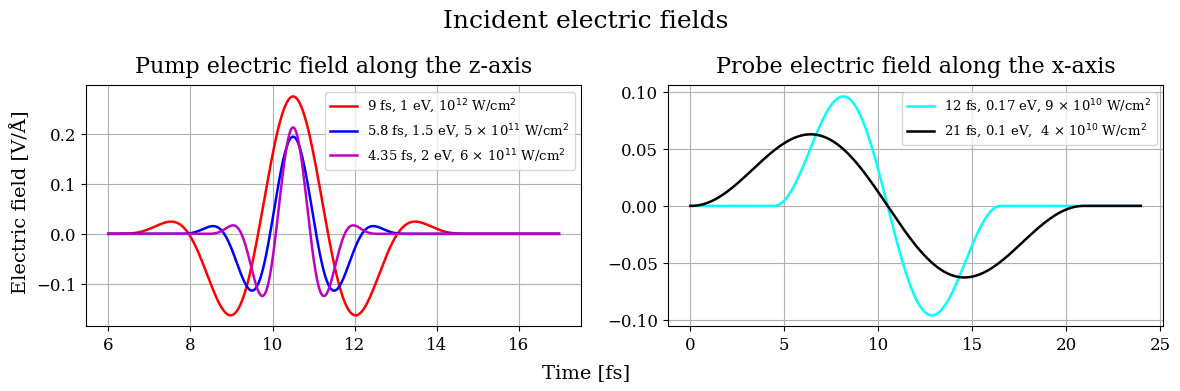

In [55]:

# ===============================
# Настройки размеров шрифтов
# ===============================

label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 9.5
title_fontsize = 16
suptitle_fontsize = 18

# ===============================
# Создание figure
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

# ===============================
# Первый график (pump z)
# ===============================
colors=['r', 'b', 'm']
labels=[r'9 fs, 1 eV, 10$^{{12}}$ W/cm$^2$', r'5.8 fs, 1.5 eV, 5 × 10$^{{11}}$ W/cm$^2$', r'4.35 fs, 2 eV, 6 × 10$^{{11}}$ W/cm$^2$']

rf"{value} × 10$^{{{power}}}$ W/cm$^2$"
max_vals1=[]
j=0
for main_folder in [folder1, folder3, folder5]:

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')

    # E_eV, spec = fft_to_eV(
    #     0.02,
    #     df['El_f_pump_z'],
    #     window='blackman',
    #     power=True,
    #     pad_factor=10
    # )

    ax1.plot(df['time'][300:850],  df['El_f_pump_z'][300:850],
             linewidth=1.8, color=colors[j], label=labels[j])
    j=j+1
    max_vals1.append(E_eV[np.argmax(spec)])

ax1.set_title('Pump electric field along the z-axis', fontsize=title_fontsize, y=1.02)
ax1.grid(True)
ax1.legend(fontsize=legend_fontsize)


# ===============================
# Второй график (probe x)
# ===============================
colors=['aqua', 'black']
labels=[r'12 fs, 0.17 eV, 9 × 10$^{{10}}$ W/cm$^2$', r'21 fs, 0.1 eV,  4 × 10$^{{10}}$ W/cm$^2$']
max_vals2=[]
j=0
for main_folder in [folder7, folder5]:

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')

    # E_eV, spec = fft_to_eV(
    #     0.02,
    #     df['El_f_probe_x'],
    #     window='blackman',
    #     power=True,
    #     pad_factor=10
    # )
    if main_folder == folder7:
        arr = np.array(df['El_f_probe_x'])
        n = 225
        result = np.roll(arr, n)
        ax2.plot(df['time'][:1200],  result[:1200],
             linewidth=1.8, color=colors[j], label=labels[j])
    else:
        ax2.plot(df['time'][:1200],  df['El_f_probe_x'][:1200],
                 linewidth=1.8, color=colors[j], label=labels[j])
    j=j+1
    max_vals2.append(E_eV[np.argmax(spec)])

ax2.set_title('Probe electric field along the x-axis', fontsize=title_fontsize, y=1.02)
ax2.grid(True)
ax2.legend(fontsize=legend_fontsize)


# ===============================
# Общие подписи осей
# ===============================

fig.supxlabel('Time [fs]', fontsize=label_fontsize, y=0.05)
fig.supylabel(r'Electric field [V/Å]', fontsize=label_fontsize)

# ===============================
# Общий заголовок
# ===============================

fig.suptitle('Incident electric fields',
             fontsize=suptitle_fontsize, y=0.98)

# ===============================
# Размеры тиков
# ===============================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

# ===============================
# Отступы
# ===============================

plt.tight_layout()


plt.savefig("thesis_plots/hhg/" + 'pulses_electric_fields.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/hhg/" + 'pulses_electric_fields.pdf', bbox_inches="tight")

plt.show()
plt.close()

## drude

### current x

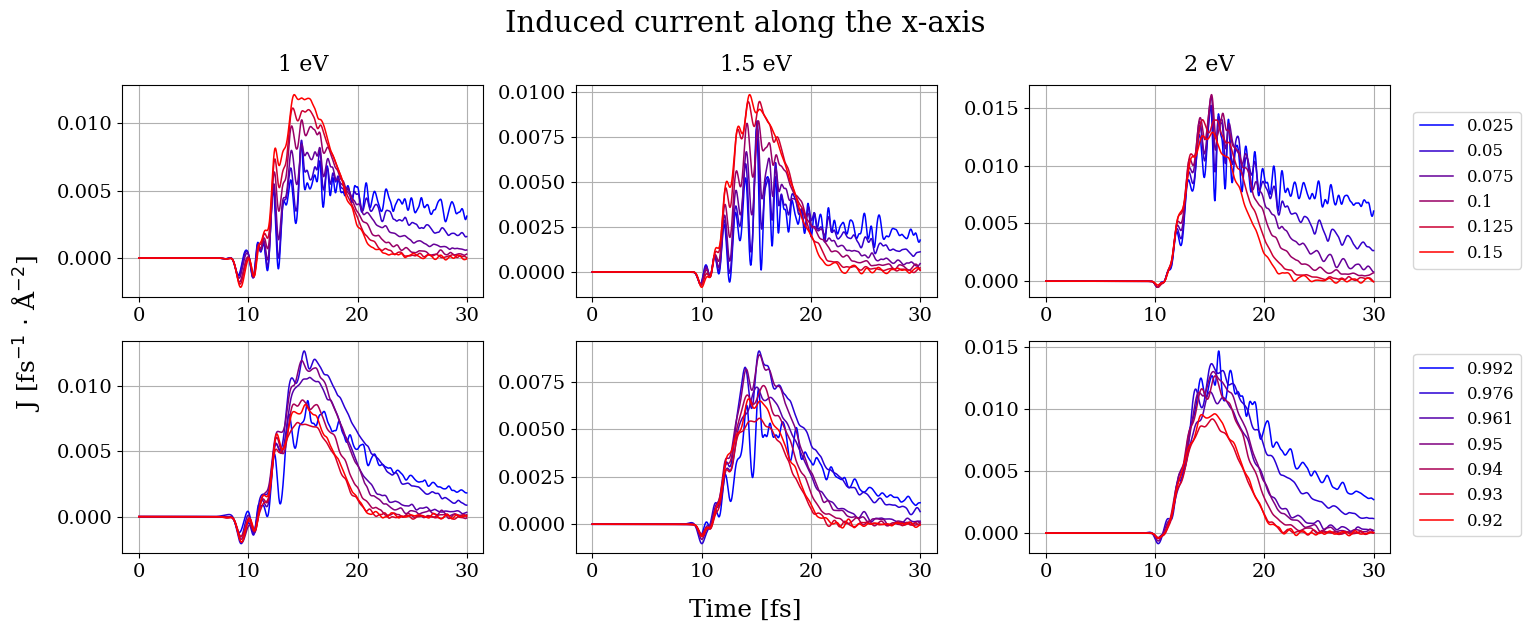

In [56]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Induced current along the x-axis'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(len(filenames_arr))
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(6)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if ('amorphous' in f) or (extract_s_num(f[:-4])<0.16):
            ax.plot(
                df['time'], df['Jm_both_x']-df['Jm_pump_x']-df['Jm_probe_x'],
                color=colors[j],
                label=label_name, linewidth=1.1
            )

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('J [fs$^{-1}$ $\\cdot$ Å$^{-2}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/drude/png/" + 'delta_x_current_response_comparison.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/drude/pdf/" + 'delta_x_current_response_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

### get tau drude x

#### funcs

In [84]:
def effecive_mass_model(alpha, a, b, c):
    return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [85]:
def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
    # t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    
    step_dt = 0.02


    # нужно в окружении задать t, El_f_probe_x и правильно определить константы m0
    
    dt = np.diff(t, prepend=t[0])
    
    
    alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
    fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
    alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_2:])         # сетка времени
    E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0

    
    for k in range(len(t_array)-1):
            j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])
    
    return j_euler[::1]

#### drude fit

In [86]:
# tau_x_drude, tau_x_drude_errs

In [87]:
def moving_average_time(signal, dt, window_width, mode='reflect'):

    signal = np.asarray(signal)

    # перевод ширины окна в количество точек
    window_size = int(round(window_width / dt))
 
    kernel = np.ones(window_size) / window_size

    pad = window_size // 2
    padded = np.pad(signal, pad, mode=mode)

    avg = np.convolve(padded, kernel, mode='valid')

    return avg[1:]

In [88]:


def finite_diff_weights(n_points, derivative_order=1):
    if n_points % 2 == 0:
        raise ValueError("n_points должно быть нечётным")
    if derivative_order < 0 or derivative_order >= n_points:
        raise ValueError("derivative_order должно быть < n_points")

    m = n_points // 2
    x = np.arange(-m, m + 1, dtype=float)

    A = np.zeros((n_points, n_points), dtype=float)
    for i in range(n_points):
        A[i] = x**i

    b = np.zeros(n_points, dtype=float)
    b[derivative_order] = math.factorial(derivative_order)

    return np.linalg.solve(A, b)

def derivative(y, dt, n_points=5):
    y = np.asarray(y, dtype=float)
    if y.size < n_points:
        raise ValueError("Длина массива y должна быть >= n_points")

    coeffs = finite_diff_weights(n_points, derivative_order=1)
    m = n_points // 2

    dydt = np.empty_like(y)
    dydt[:] = np.nan  # для отладки/контроля

    # центральная формула
    for i in range(m, len(y) - m):
        dydt[i] = np.dot(coeffs, y[i - m:i + m + 1]) / dt

    # заполняем края ближайшим корректным значением (без разрыва)
    dydt[:m] = dydt[m]
    dydt[len(y) - m:] = dydt[len(y) - m - 1]

    return dydt

In [159]:
def fit_smoothing_spline(x, y, *, k=3, s=None, w=None, sort=True):
    """
    Строит сглаживающий сплайн S(x) по данным (x, y).

    Параметры:
      x, y : 1D массивы
      k    : степень сплайна (полинома в кусках), обычно 1..5. Часто k=3 (кубический).
      s    : параметр сглаживания (None -> дефолт SciPy; меньше -> ближе к точкам)
      w    : веса (None или 1D массив той же длины)
      sort : сортировать ли по x (обычно нужно)

    Возвращает:
      spl : объект UnivariateSpline (его можно вызывать spl(x_new))
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.ndim != 1 or y.ndim != 1 or len(x) != len(y):
        raise ValueError("x и y должны быть 1D массивами одинаковой длины")

    if w is not None:
        w = np.asarray(w, dtype=float)
        if w.shape != y.shape:
            raise ValueError("w должен быть той же формы, что и y")

    if not (1 <= k <= 5):
        raise ValueError("k (степень сплайна) обычно в диапазоне 1..5")

    if sort:
        idx = np.argsort(x)
        x, y = x[idx], y[idx]
        if w is not None:
            w = w[idx]

    # UnivariateSpline сам строит сглаживающий сплайн (если s>0) или интерполяционный (если s=0)
    spl = UnivariateSpline(x, y, w=w, k=k, s=s)
    return spl

In [160]:
def derivative_multipt(x, y, points=5):
    """
    Первая производная dy/dx через симметричную сумму по соседним точкам.
    
    Параметры:
        x, y  : 1D массивы одинаковой длины
        points: нечётное число точек в окне (3,5,7,...)
                points = 2m+1
    
    Требование:
        x должен быть равномерным
    
    Возвращает:
        dydx (той же длины)
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x и y должны быть одной длины")

    if points % 2 == 0 or points < 3:
        raise ValueError("points должно быть нечётным числом >= 3")

    n = len(x)
    h = np.mean(np.diff(x))  # предполагаем равномерную сетку
    m = points // 2

    dydx = np.zeros(n)

    # === Центральная формула (внутренние точки) ===
    for i in range(m, n - m):
        for k in range(1, m + 1):
            dydx[i] += k * (y[i + k] - y[i - k])
        dydx[i] /= (h * sum([2 * k**2 for k in range(1, m + 1)]))

    # === Левый край (пониженный порядок) ===
    for i in range(m):
        dydx[i] = (y[i + 1] - y[i]) / h

    # === Правый край ===
    for i in range(n - m, n):
        dydx[i] = (y[i] - y[i - 1]) / h

    return dydx

In [ ]:
spl = fit_smoothing_spline(t, delta_Jm_x, s=5e-5, k=5)
J_smooth = spl(t)

plt.plot(t, delta_Jm_x)
plt.plot(t, J_smooth)

plt.figure()

plt.plot(t, derivative_multipt(t, J_smooth, points=5))

all_data/main/1eV/sigma/21fs/4d10/1d12/all_data_v2_Jan28_1eV_21fs_sigma


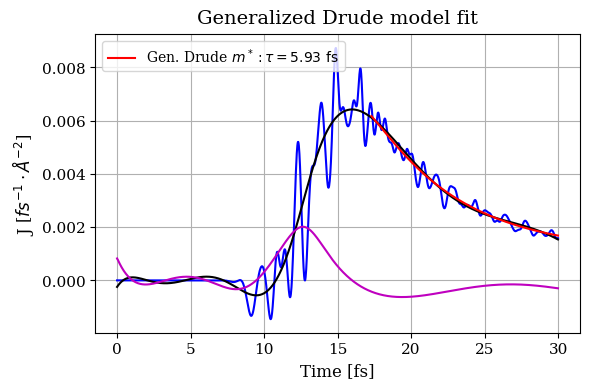

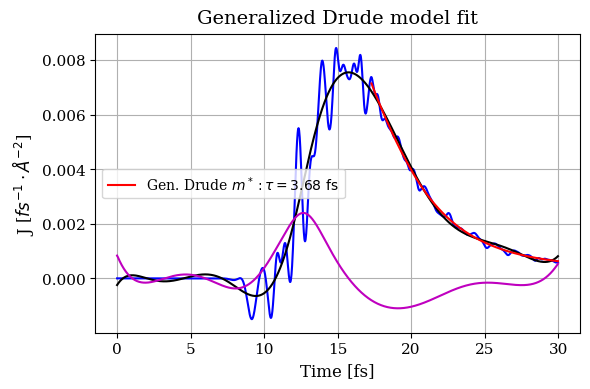

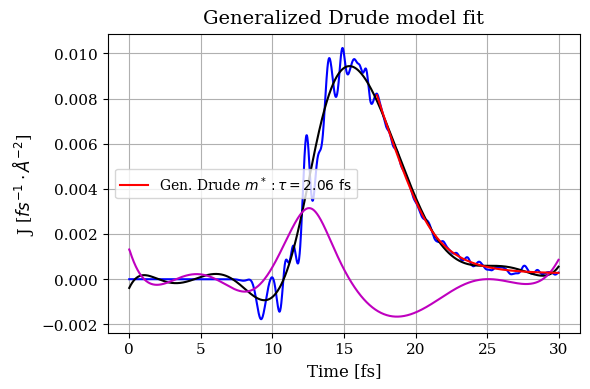

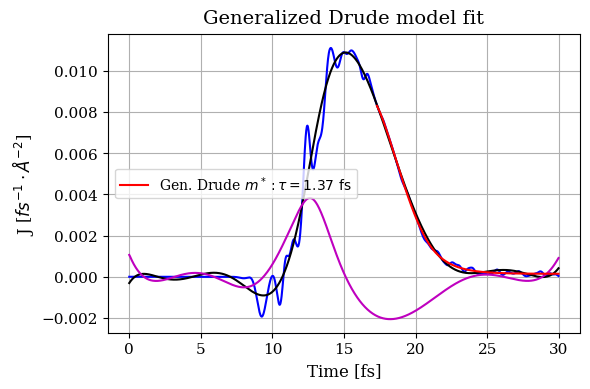

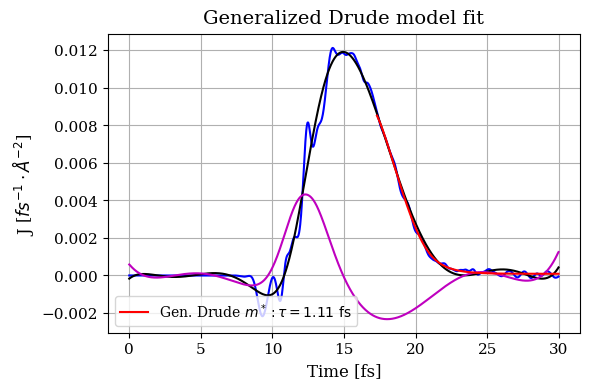

In [323]:
tau_x_drude_main_folders=[]


folder1_spline_s=[1.7e-4, 2.1e-4, 2.05e-4, 2.2e-4, 2.4e-4, 2.5e-4]

m_k_vals_arr=[]

for main_folder in [folder1]:
    
    num_folder=0
    
    new_taus = []
    new_j_finals = []
    arr_abc = []
    
    tau_x_drude=[]
    tau_x_drude_errs=[]
    
    alphas_start = []
    alphas_final = []
    
    # delta_start_drude_fit = 50
    delta_start_drude_fit = 340
    # folder1,2:300  folder3: 1-fit doesn't work


    files_path = Path(main_folder) / "n_ex" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')
    
    n_ex_vals_arr = df['both_n_ex']

    
    
    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    
    print(main_folder)
    for j, f in enumerate(filenames_arr[1:6]):
        
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')
    
        # plt.plot(df['time'], df['Jm_both_x']-df['Jm_pump_x']-df['Jm_probe_x'])
        # plt.plot(df['time'], df['El_f_probe_x']/10)
    
        t = df['time']
        El_f_probe_x = df['El_f_probe_x']
        delta_Jm_x = df['Jm_both_x']-df['Jm_pump_x']-df['Jm_probe_x']
    
    
        m0_cut_1 =   1050           # duration of probe pulse for exp fit after it
        m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
        
        m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
        
        
        dt = np.diff(t, prepend=t[0])
        
        alpha_arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+100]*dt[m0_cut_3:m0_cut_1+100]))
        a_start = alpha_arr[m0_cut_2-m0_cut_3]
        a_fin = alpha_arr[-1]
        
        alphas_start.append(a_start)
        alphas_final.append(a_fin)
    
    
    
        fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
        plt.figure(figsize=(6,4))
        plt.title("Generalized Drude model fit", fontsize=14, y=1.01)
        plt.plot(t, delta_Jm_x, color='b')

        
        spl = fit_smoothing_spline(t, delta_Jm_x, s=folder1_spline_s[j+1]*(0.15/extract_s_num(f[:-4])), k=5)
            
        J_smooth = spl(t)
        # av_delta_Jm_x = moving_average_time(moving_average_time(delta_Jm_x, 0.02, 1), 0.02, 1)
        plt.plot(t, J_smooth, color='black')

        deriv_J_smooth = derivative_multipt(t, J_smooth, points=5)
        # deriv_av_delta_Jm_x = moving_average_time(derivative(av_delta_Jm_x, 0.02, n_points=5), 0.02, 2)
        plt.plot(t, derivative_multipt(t, J_smooth, points=5), color='m')


        spl = fit_smoothing_spline(t, derivative_multipt(t, J_smooth, points=5), s=1e-4, k=5)
        smooth_deriv_J_smooth = spl(t)
        # deriv_av_delta_Jm_x = moving_average_time(derivative(av_delta_Jm_x, 0.02, n_points=5), 0.02, 2)
        # plt.plot(t, smooth_deriv_J_smooth, color='aqua')

        
        
        
        plt.xlabel("Time [fs]", fontsize=12)
        plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)
        
        plt.xticks(fontsize=11)
        plt.yticks(fontsize=11)
        
        
        
        t_array_cut = np.array(t[m0_cut_2:])[::1]
        j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
        # (dummy_t, j0, fit_alpha, j_final)
        p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
        # print(len(t_array_cut), len(j_exp))
        popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
        [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
        ))
        j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
        j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)

        m_k = -17.56*n_ex_vals_arr[j+1]/((np.array(deriv_J_smooth + (J_smooth-fit_j_fin_val)/fit_tau_val)[m0_cut_3+50:m0_cut_1-150])/np.array(El_f_probe_x)[m0_cut_3+50:m0_cut_1-150])
        
        # plt.plot(t[m0_cut_3+50:m0_cut_1-150], 
        # m_k, color='orange')
    

        m_k_vals_arr.append((alpha_arr[50:m0_cut_1-m0_cut_3-150], m_k))

        
        perr = np.sqrt(np.diag(pcov))
        # print("errors are: ", perr)
        tau_x_drude_errs.append(perr[-2])
        
        tau_x_drude.append(fit_tau_val)
        new_j_finals.append(fit_j_fin_val)
        
        plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
        plt.legend(fontsize=10)
        plt.grid()
        arr_abc.append((a, b, c))
        # print(a, b, c)
        
        plt.tight_layout()
        
        
        plt.show()
        plt.close()

    tau_x_drude_main_folders.append(tau_x_drude)
    
    


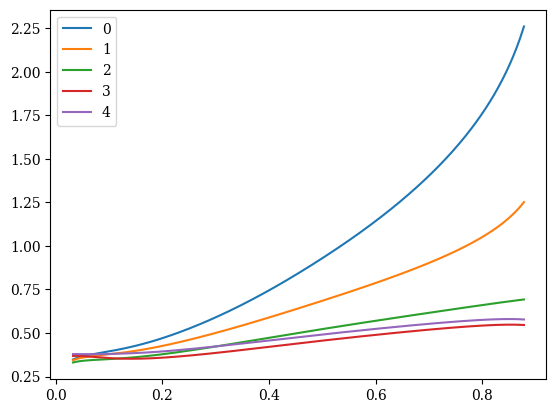

In [324]:
for i in range(5):
    plt.plot(m_k_vals_arr[i][0], m_k_vals_arr[i][1], label=str(i))
    plt.legend()

In [288]:
m0_cut_3

525

In [270]:
len(alpha_arr[50:m0_cut_1-550])

450

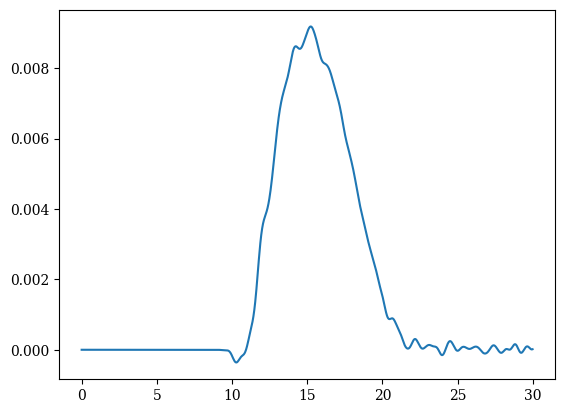

In [99]:
plt.plot(t, delta_Jm_x)

In [64]:
# tau_x_drude_main_folders
# tau_x_drude_main_folders[0][1:]

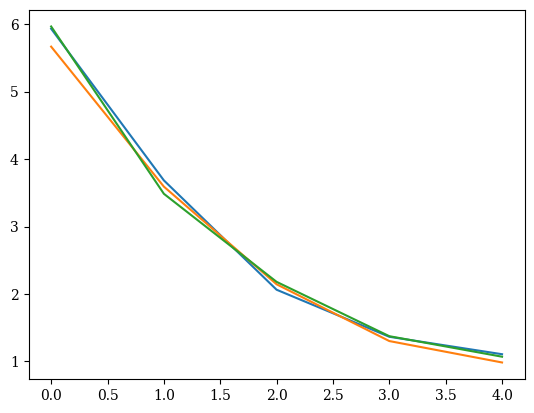

In [65]:
plt.plot(tau_x_drude_main_folders[0][1:])
plt.plot(tau_x_drude_main_folders[2][1:])
plt.plot(tau_x_drude_main_folders[4][1:])

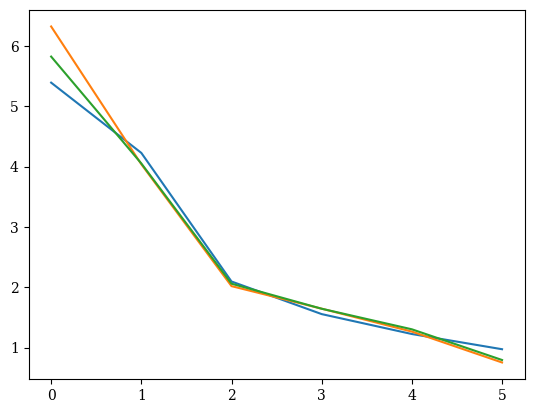

In [66]:
plt.plot(tau_x_drude_main_folders[1])
plt.plot(tau_x_drude_main_folders[3])
plt.plot(tau_x_drude_main_folders[5])

## fid

### current z

#### funcs

In [67]:
def moving_average_time(signal, dt, window_width, mode='reflect'):

    signal = np.asarray(signal)

    # перевод ширины окна в количество точек
    window_size = int(round(window_width / dt))
 
    kernel = np.ones(window_size) / window_size

    pad = window_size // 2
    padded = np.pad(signal, pad, mode=mode)

    avg = np.convolve(padded, kernel, mode='valid')

    return avg[1:]

In [68]:
def coherence_time(Y, dt) -> float:
    r"""
    Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

    The function implements Mandel's coherence time. It calculates the autocorrelation
    function of the given signal, then it calculates the complex envelope of the
    autocorrelation function, and integrates the square of the normalized envelope from
    t=0 to the maximal time. The coherence time is twice the value of the integral.

    Args:
      Y: 1D array that represents the time-dependent signal on a regular grid.
      dt: Time step of the grid.

    Returns:
      the coherence time as a floating-point number.
    """
    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING

    try:
        return 2.0 * scipy.integrate.simps(ACF_envelope[i1:]**2, dx=dt)
    except Exception:
        return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

In [69]:
def get_autocorr_envelope(Y, dt):

    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING
    
    return ACF_envelope[i1:]

In [70]:
def coherence_time_v2_abs(Y, dt) -> float:
    # autocorrelation of abs of the signal and then Mandel's integration
    ACF = scipy.signal.correlate(abs(Y), abs(Y), mode="full", method="direct") # autocorrelation function
    ACF = ACF/max(ACF)
    N = len(Y)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    
    try:
        return 2.0 * scipy.integrate.simps(ACF[i1:]**2, dx=dt)
    except Exception:
        # print("No scipy.integrate.simps function")
        return 2.0 * scipy.integrate.simpson(ACF[i1:]**2, dx=dt)

In [71]:
def find_halfcycle_maxima(t, y):
    """
    Находит координаты всех локальных максимумов:
    y'(t)=0 и y''(t)<0
    Возвращает массивы t_max, y_max
    """
    
    # первая и вторая производные
    dy = np.gradient(y, t)
    d2y = np.gradient(dy, t)

    # условие смены знака производной + на -
    sign_change = np.where(
        (dy[:-1] > 0) & (dy[1:] <= 0)
    )[0]

    # фильтрация по второй производной < 0
    maxima_indices = [
        i for i in sign_change if d2y[i] < 0
    ]

    t_max = t[maxima_indices]
    y_max = y[maxima_indices]

    return np.array(t_max), np.array(y_max)

In [72]:
def exp_gauss(t, A, tau, t0, sigma, C):
    return A * np.exp(-t / new_taus[j-1]) * np.exp(-(0*t)**2 / (2 * sigma**2)) + C**2


def fit_exp_gauss(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    A0 = np.max(y) - np.min(y)
    tau0 = 2
    t0_0 = 0
    sigma0 = 1
    C0 = np.min(y)

    p0 = [A0, tau0, t0_0, sigma0, C0]

    popt, pcov = curve_fit(exp_gauss, t, y, p0=p0, maxfev=10000)

    return popt, pcov

In [73]:
def gaussian_convolve(y, sigma):
    """
    Свёртка массива y с гауссовым ядром.
    
    sigma — стандартное отклонение в точках.
    """
    y = np.asarray(y)
    
    # длина ядра (берём ±4σ)
    radius = int(4 * sigma)
    x = np.arange(-radius, radius + 1)
    
    # гауссово ядро
    kernel = np.exp(-x**2 / (2 * sigma**2))
    kernel /= kernel.sum()  # нормировка
    
    # линейная свёртка (без периодичности)
    y_smooth = np.convolve(y, kernel, mode='same')
    
    return y_smooth

In [74]:
def fourier_plot(fid_signal, convolve_val):

    N = len(fid_signal)
    
    # убираем среднее (рекомендовано)
    x = np.array(fid_signal)-np.mean(fid_signal)
    
    # FFT
    M=5
    xpad = np.pad(x, (0, (M-1)*len(x)))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs
    
    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696                # eV·fs
    E_eV = h_eV_fs * freq
    
    # амплитуда
    A = np.abs(X)
    
    # график
    # plt.plot(E_eV, gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val)), color='b')
    # plt.xlabel("Energy (eV)")
    # plt.ylabel("|FFT|")
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)
    # plt.grid()
    # plt.show()
    A = A[:int(110*M/4)]

    return E_eV[:int(110*M/4)], gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val))

#### cco

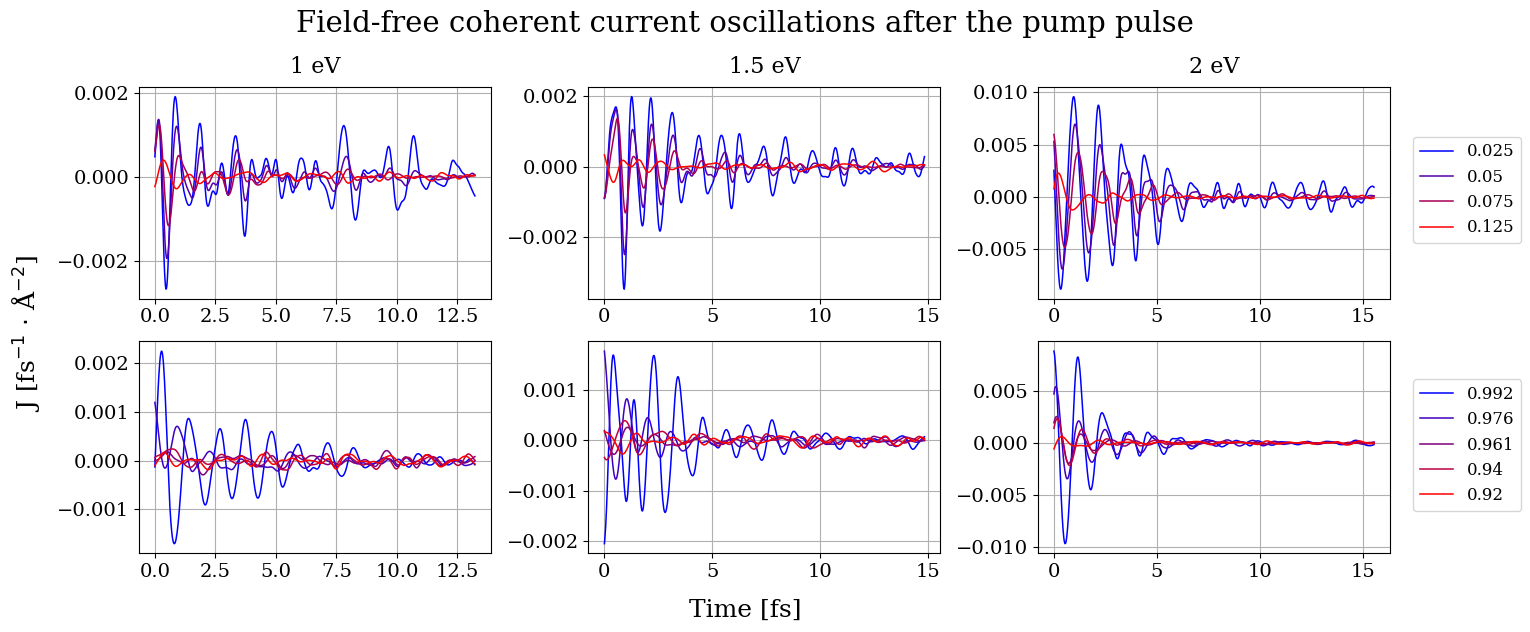

In [75]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Field-free coherent current oscillations after the pump pulse'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        # continue
        main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "current_energy" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])

    if '1eV' in main_folder:
        t1, t2 = (838, 1500)
    if '1.5eV' in main_folder:
        t1, t2 = (758, 1500)
    if '2eV' in main_folder:
        t1, t2 = (722, 1500)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    # colors = blue_red_gradient(len(filenames_arr))
    colors = blue_red_gradient(5)
    color_j=0
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(4)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[:-4])
        df = pd.read_csv(files_path / f, comment='#')

        if (('amorphous' in f) or (extract_s_num(f[:-4])<0.16)) and (j%2==0 or j==1):
            fid_signal = df['Jm_both_z'][t1:t2] - moving_average_time(df['Jm_both_z'][t1:t2], 0.02, 5)
            ax.plot(
                df['time'][t1:t2]-df['time'][t1],
                fid_signal,
                color=colors[color_j],
                label=label_name, linewidth=1.1
            )
            color_j=color_j+1

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Time [fs]', fontsize=axis_label_size, y=0.02)
fig.supylabel('J [fs$^{-1}$ $\\cdot$ Å$^{-2}$]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/cco/png/" + 'coherent_current_oscillations.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'coherent_current_oscillations.pdf', bbox_inches="tight")

plt.show()
plt.close()

#### cco spectrum

In [76]:
# files_path = Path(folder1) / "fid_data" / "fid" / "z" / "data"
# filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
# filenames_arr = [f for f in filenames_arr if 'spectral_intensity' in f]

# df = pd.read_csv(files_path / filenames_arr[0], comment='#')

# plt.plot(df['energies'], df['F_fid'])

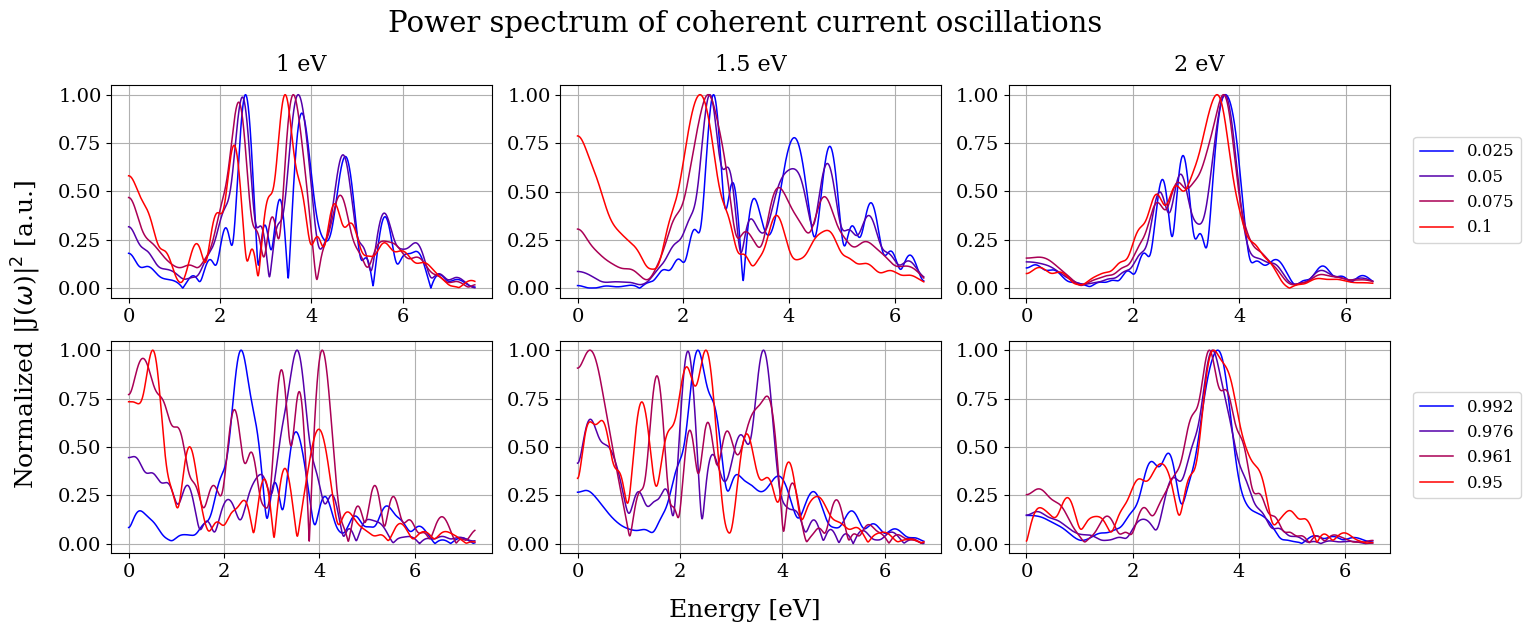

In [77]:
# ================= НАСТРОЙКИ =================
figsize = (15, 6)

# размеры текста
col_title_size = 16
axis_label_size = 18
tick_size = 14
suptitle_size = 21

# сдвиг заголовков столбцов
col_title_shift_x = 0.0
col_title_shift_y = 0.015

# общая подпись (suptitle)
suptitle_text = 'Power spectrum of coherent current oscillations'
suptitle_x = 0.5
suptitle_y = 1.04

# легенды справа (по одной на строку)
legend_fontsize = 12
legend_x = 0.94
legend_y_top = 0.74
legend_y_bottom = 0.315

# tight_layout: оставляем место справа под легенды и сверху под подписи
tight_right = 0.94     # чем меньше, тем больше места справа
tight_top = 0.94
# =============================================

fig, axes = plt.subplots(2, 3, figsize=figsize)

# ---------- Построение графиков ----------
for i, main_folder in enumerate(main_folders):
    if not main_folder:
        continue
        # main_folder='all_data/main/'+tree['1.5eV']['amorphous']['12fs']['3d10']['5d11']

    # заполнение по столбцам: (0,0)->(1,0)->(0,1)->(1,1)->(0,2)->(1,2)
    r = i % 2
    c = i // 2
    ax = axes[r, c]

    files_path = Path(main_folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'spectral_intensity' in f]

    if '1eV' in main_folder:
        t1, t2 = (285, 1060)
    if '1.5eV' in main_folder:
        t1, t2 = (325, 1040)
    if '2eV' in main_folder:
        t1, t2 = (410, 1015)
        
    if '12fs' in main_folder:
        t1, t2 = (100, 815)

    colors = blue_red_gradient(4)
    col_idx=0
    if not ('amorphous' in filenames_arr[0]):
        colors=blue_red_gradient(4)

    ax.grid(True)

    for j, f in enumerate(filenames_arr):
        if (j<4 and j%1==0):
            label_name = extract_amorphous_value(f[:-4]) if 'amorphous' in f else extract_s_num(f[20:-4])
            df = pd.read_csv(files_path / f, comment='#')
        
            if ('amorphous' in f) or (extract_s_num(f[20:-4])<0.16):
                ax.plot(
                    df['energies'], df['F_fid'],
                    color=colors[col_idx],
                    label=label_name, linewidth=1.1
                )
                col_idx=col_idx+1
            # ax.set_yscale('log')

    ax.tick_params(labelsize=tick_size)
    # ВАЖНО: тут НЕ делаем ax.legend() — легенды будут общими справа

# ---------- Общие подписи осей ----------
fig.supxlabel('Energy [eV]', fontsize=axis_label_size, y=0.02)
fig.supylabel(r'Normalized |J($\omega$)|$^2$ [a.u.]', fontsize=axis_label_size, x=0.01)

# layout (оставляем место справа под легенды и сверху под подписи)
plt.tight_layout(rect=(0, 0, tight_right, tight_top))
fig.canvas.draw()  # обновить позиции осей после layout

# ---------- Заголовки столбцов (строго по центру) ----------
col_titles = ['1 eV', '1.5 eV', '2 eV']
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    x_center = pos.x0 + pos.width / 2 + col_title_shift_x
    y_top = pos.y1 + col_title_shift_y
    fig.text(x_center, y_top, title, ha='center', va='bottom', fontsize=col_title_size)

# ---------- Общая подпись сверху ----------
fig.suptitle(suptitle_text, fontsize=suptitle_size, x=suptitle_x, y=suptitle_y, ha='center')

# ---------- Легенды справа: по одной на строку ----------
# Берём handles/labels из первой оси каждой строки (там уже есть label=...)
handles_top, labels_top = axes[0, 0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[1, 0].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_top),
    fontsize=legend_fontsize,
    frameon=True
)

fig.legend(
    handles_bottom, labels_bottom,
    loc='center left',
    bbox_to_anchor=(legend_x, legend_y_bottom),
    fontsize=legend_fontsize,
    frameon=True
)

# plt.tight_layout()

plt.savefig("thesis_plots/cco/png/" + 'coherent_current_oscillations_spectrum.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'coherent_current_oscillations_spectrum.pdf', bbox_inches="tight")

plt.show()
plt.close()

#### tau plots

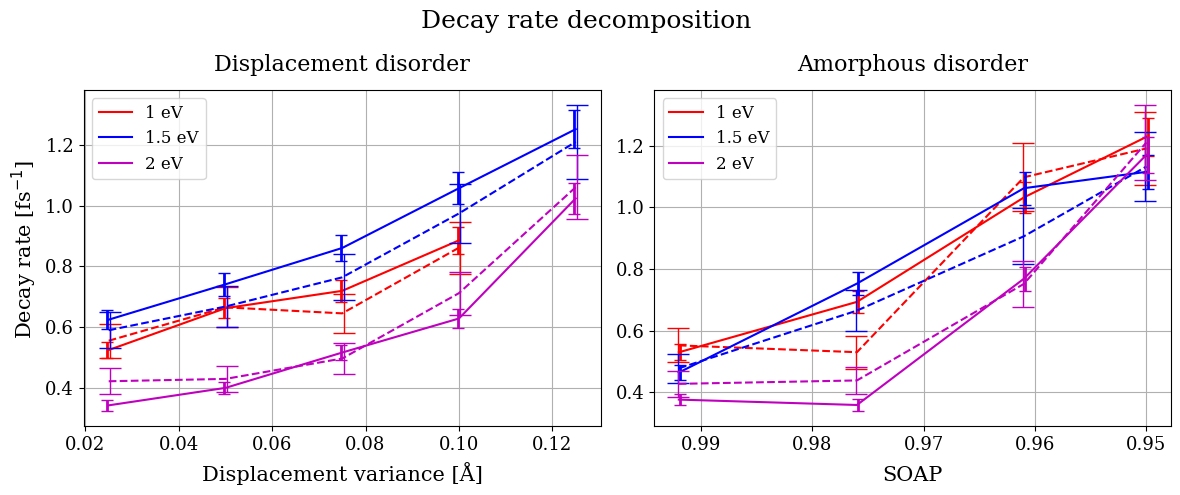

In [78]:
tau_x_drude_arr_sigma=np.array([8.06247981, 5.88323652, 3.67338893, 2.05586172, 1.35875196,
       1.10176995, 0.61276261, 0.6973946 ])


# ===============================
# Настройки размеров шрифтов
# ===============================

label_fontsize = 15
tick_fontsize = 13
legend_fontsize = 12
title_fontsize = 16
suptitle_fontsize = 18

column_title_fontsize=16

# ===============================
# Создание figure
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1, ax2 = axes

# ===============================
# Первый график (pump z)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals1=[]
j=0
for folder in [folder1, folder3, folder5]:
    files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')


    if '1eV' in folder:
        ax1.plot(sigma_disorders[:4], 1/df['tau_z_coh'][:4], color=colors[j], label=labels[j], linewidth=1.5)

        ax1.errorbar(
        np.array(sigma_disorders[:4])-0.0003,
        1/df['tau_z_coh'][:4],
        yerr=0.05 * 1/np.array(df['tau_z_coh'][:4]),
        fmt='none',
        color=colors[j], elinewidth=2, capsize=4
    )
        
        ax1.plot(sigma_disorders[:4], 1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4], linestyle='--', color=colors[j], linewidth=1.5)

        ax1.errorbar(
        np.array(sigma_disorders[:4])+0.0003,
        1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4],
        yerr=0.1 * np.array(1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4]),
        fmt='none',
        color=colors[j], elinewidth=1, linestyle='--', capsize=8
    )
        
        
    else:
        ax1.plot(sigma_disorders[:5], 1/df['tau_z_coh'][:5], color=colors[j], label=labels[j], linewidth=1.5)


        ax1.errorbar(
        np.array(sigma_disorders[:5])-0.0003,
        1/df['tau_z_coh'][:5],
        yerr=0.05 * 1/np.array(df['tau_z_coh'][:5]),
        fmt='none',
        color=colors[j], elinewidth=2, capsize=4)
    
        
        ax1.plot(sigma_disorders[:5], 1/tau_x_drude_arr_sigma[:5] + 1/df['tau_z_norm_coh'][:5], linestyle='--', color=colors[j], linewidth=1.5)


        ax1.errorbar(
        np.array(sigma_disorders[:5])+0.0003,
        1/tau_x_drude_arr_sigma[:5] + 1/df['tau_z_norm_coh'][:5],
        yerr=0.1 * np.array(1/tau_x_drude_arr_sigma[:5] + 1/df['tau_z_norm_coh'][:5]),
        fmt='none',
        color=colors[j], elinewidth=1, linestyle='--', capsize=8)
    
    
    # ax1.plot(E_eV[:300], spec[:300] / max(spec),
    #          linewidth=1.8, color=colors[j], label=labels[j])
    
    j=j+1



ax1.set_xlabel('Displacement variance [Å]', fontsize=label_fontsize, labelpad=6)
ax1.grid()
ax1.set_title('Displacement disorder', fontsize=column_title_fontsize, y=1.03)

ax1.legend(fontsize=legend_fontsize)


# ===============================
# Второй график (probe x)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals2=[]
j=0
for folder in [folder2, folder4, folder6]:
    files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')


    ax2.plot(amorph_disorders[:4], 1/df['tau_z_coh'][:4], color=colors[j], label=labels[j], linewidth=1.5)


    ax2.errorbar(
    np.array(amorph_disorders[:4])-0.0001,
    1/df['tau_z_coh'][:4],
    yerr=0.05 * 1/np.array(df['tau_z_coh'][:4]),
    fmt='none',
    color=colors[j], elinewidth=2, capsize=4)
    
    
    ax2.plot(amorph_disorders[:4], 1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4], linestyle='--', color=colors[j], linewidth=1.5)


    ax2.errorbar(
    np.array(amorph_disorders[:4])+0.0001,
    1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4],
    yerr=0.1 * np.array(1/df['tau_x_drude'][:4] + 1/df['tau_z_norm_coh'][:4]),
    fmt='none',
    color=colors[j], elinewidth=1, linestyle='--', capsize=8)
    

    j=j+1


ax2.set_xlabel('SOAP', fontsize=label_fontsize, labelpad=9)
ax2.grid()
ax2.set_title('Amorphous disorder', fontsize=column_title_fontsize, y=1.03)
ax2.invert_xaxis()

ax2.legend(fontsize=legend_fontsize)


# ===============================
# Общие подписи осей
# ===============================

# fig.supxlabel('Energy [eV]', fontsize=label_fontsize, y=0.05)
fig.supylabel(r'Decay rate [fs$^{-1}$]', fontsize=label_fontsize)

# ===============================
# Общий заголовок
# ===============================

fig.suptitle('Decay rate decomposition',
             fontsize=suptitle_fontsize, y=0.98)

# ===============================
# Размеры тиков
# ===============================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

# ===============================
# Отступы
# ===============================

plt.tight_layout()


plt.savefig("thesis_plots/cco/png/" + 'cco_decay_rate_decomposition.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'cco_decay_rate_decomposition.pdf', bbox_inches="tight")

plt.show()
plt.close()

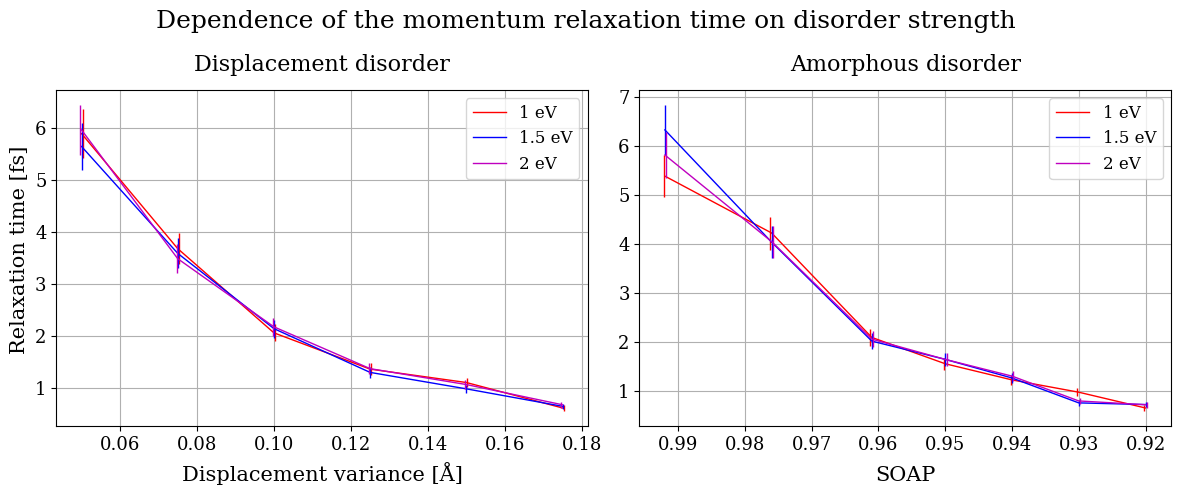

In [79]:
tau_x_drude_arr_sigma=np.array([8.06247981, 5.88323652, 3.67338893, 2.05586172, 1.35875196,
       1.10176995, 0.61276261, 0.6973946 ])


# ===============================
# Настройки размеров шрифтов
# ===============================

label_fontsize = 15
tick_fontsize = 13
legend_fontsize = 12
title_fontsize = 16
suptitle_fontsize = 18

column_title_fontsize=16

# ===============================
# Создание figure
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1, ax2 = axes

# ===============================
# Первый график (pump z)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals1=[]
j=0
for folder in [folder1, folder3, folder5]:
    files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')



    ax1.plot(sigma_disorders[1:7], df['tau_x_drude'][1:7], color=colors[j], label=labels[j], linewidth=1)


    ax1.errorbar(
    np.array(sigma_disorders[1:7])-(j-1)*0.0003,
    df['tau_x_drude'][1:7],
    yerr=0.08 * np.array(df['tau_x_drude'][1:7]),
    fmt='none',
    color=colors[j], elinewidth=1)
        
    
    
    # ax1.plot(E_eV[:300], spec[:300] / max(spec),
    #          linewidth=1.8, color=colors[j], label=labels[j])
    
    j=j+1



ax1.set_xlabel('Displacement variance [Å]', fontsize=label_fontsize, labelpad=6)
ax1.grid()
ax1.set_title('Displacement disorder', fontsize=column_title_fontsize, y=1.03)

ax1.legend(fontsize=legend_fontsize)


# ===============================
# Второй график (probe x)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals2=[]
j=0
for folder in [folder2, folder4, folder6]:
    files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')


    ax2.plot(amorph_disorders[:7], df['tau_x_drude'][:7], color=colors[j], label=labels[j], linewidth=1)


    ax2.errorbar(
    np.array(amorph_disorders[:7])-(j-1)*0.0002,
    df['tau_x_drude'][:7],
    yerr=0.08 * np.array(df['tau_x_drude'][:7]),
    fmt='none',
    color=colors[j], elinewidth=1, capsize=0*(3+(j-1)*0.5))
    
    
    j=j+1


ax2.set_xlabel('SOAP', fontsize=label_fontsize, labelpad=9)
ax2.grid()
ax2.set_title('Amorphous disorder', fontsize=column_title_fontsize, y=1.03)
ax2.invert_xaxis()

ax2.legend(fontsize=legend_fontsize)


# ===============================
# Общие подписи осей
# ===============================

# fig.supxlabel('Energy [eV]', fontsize=label_fontsize, y=0.05)
fig.supylabel('Relaxation time [fs]', fontsize=label_fontsize)

# ===============================
# Общий заголовок
# ===============================

fig.suptitle('Dependence of the momentum relaxation time on disorder strength',
             fontsize=suptitle_fontsize, y=0.98)

# ===============================
# Размеры тиков
# ===============================

for ax in axes:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

# ===============================
# Отступы
# ===============================

plt.tight_layout()


plt.savefig("thesis_plots/cco/png/" + 'momentum_relaxation_time.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'momentum_relaxation_time.pdf', bbox_inches="tight")

plt.show()
plt.close()

In [80]:
def l2_normalize(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    a = np.dot(x, y) / np.dot(x, x)
    return a, a*x

In [81]:
1/df['spectrum_width'][1:5]
np.array(df['tau_z_coh'][1:5])

array([2.78836655, 1.30125866, 0.85457478, 0.74232654])

3.1410414354626637


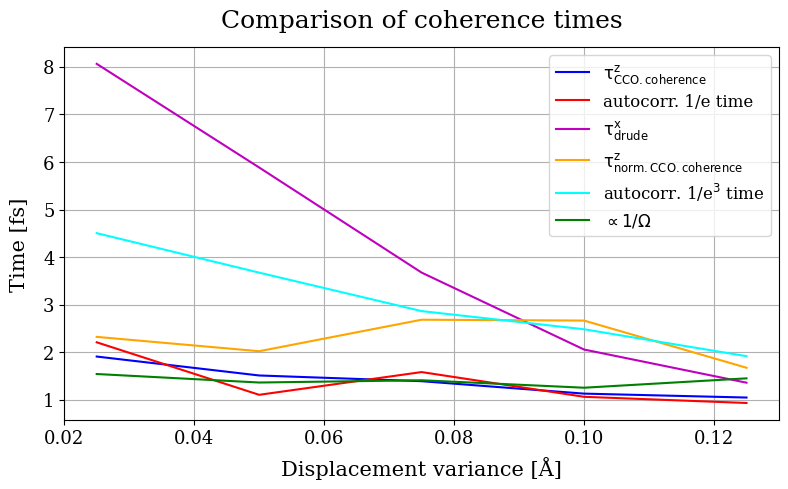

In [82]:
tau_x_drude_arr_sigma=np.array([8.06247981, 5.88323652, 3.67338893, 2.05586172, 1.35875196,
       1.10176995, 0.61276261, 0.6973946 ])


# ===============================
# Настройки размеров шрифтов
# ===============================

label_fontsize = 15
tick_fontsize = 13
legend_fontsize = 12
title_fontsize = 20
suptitle_fontsize = 18

column_title_fontsize=18

# ===============================
# Создание figure
# ===============================

fig, axes = plt.subplots(1, 1, figsize=(8, 5))

ax1 = axes

# ===============================
# Первый график (pump z)
# ===============================
colors=['r', 'b', 'm']
labels=['1 eV', '1.5 eV', '2 eV']
max_vals1=[]
j=0
for folder in [folder1]:
    files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
    df = pd.read_csv(files_path / filenames_arr[0], comment='#')



    ax1.plot(sigma_disorders[0:5], df['tau_z_coh'][0:5], label=r'$\mathrm{\tau}_{\mathrm{CCO.coherence}}^{\mathrm{z}}$', color='b')
    ax1.plot(sigma_disorders[0:5], df['tau_autocorr_1_e'][0:5], label=r'autocorr. 1/e time', color='r')

    ax1.plot(sigma_disorders[0:5], df['tau_x_drude'][0:5], label=r'$\mathrm{\tau}_{\mathrm{drude}}^{\mathrm{x}}$', color='m')
    ax1.plot(sigma_disorders[0:5], df['tau_z_norm_coh'][0:5], label=r'$\mathrm{\tau}_{\mathrm{norm.CCO.coherence}}^{\mathrm{z}}$', color='orange')

    ax1.plot(sigma_disorders[0:5], df['tau_autocorr_1_e_3'][0:5], label=r'autocorr. 1/e$^{\mathrm{3}}$ time', color='aqua')

    # ax1.plot(sigma_disorders[0:5], df['tau_autocorr_iters_coh'][0:5], label=r'autocorr. iterations', color='black')
    
    ax1.plot(sigma_disorders[0:5], l2_normalize(np.array(1/df['spectrum_width'][0:5]), np.array(df['tau_z_coh'][0:5]))[1],
             label=r'$\propto \mathrm{1/}\mathrm{\Omega}$', color='g')

    print(l2_normalize(np.array(1/df['spectrum_width'][0:5]), np.array(df['tau_z_coh'][0:5]))[0])
    
    
    # ax1.plot(E_eV[:300], spec[:300] / max(spec),
    #          linewidth=1.8, color=colors[j], label=labels[j])
    
    j=j+1



ax1.set_xlabel('Displacement variance [Å]', fontsize=label_fontsize, labelpad=6)
ax1.grid()
ax1.set_title('Comparison of coherence times', fontsize=column_title_fontsize, y=1.03)

ax1.legend(fontsize=legend_fontsize)



# ===============================
# Общие подписи осей
# ===============================

# fig.supxlabel('Energy [eV]', fontsize=label_fontsize, y=0.05)
fig.supylabel('Time [fs]', fontsize=label_fontsize)

# ===============================
# Общий заголовок
# ===============================

# fig.suptitle('Dependence of the momentum relaxation time on disorder strength',
#              fontsize=suptitle_fontsize, y=0.98)

# ===============================
# Размеры тиков
# ===============================

for ax in [axes]:
    ax.tick_params(axis='both', labelsize=tick_fontsize)

# ===============================
# Отступы
# ===============================

plt.tight_layout()


plt.savefig("thesis_plots/cco/png/" + 'сomparison_of_coherence_times.png', dpi=200, bbox_inches="tight")
plt.savefig("thesis_plots/cco/pdf/" + 'сomparison_of_coherence_times.pdf', bbox_inches="tight")

plt.show()
plt.close()

In [338]:
# for folder in [folder1, folder3, folder5]:
#     files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
#     filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
#     filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
#     df = pd.read_csv(files_path / filenames_arr[0], comment='#')

#     # plt.figure()

#     plt.plot(sigma_disorders[0:5], df['tau_z_coh'][0:5], label=folder)
#     plt.plot(sigma_disorders[0:5], df['tau_autocorr_1_e'][0:5], label=folder)

#     plt.plot(sigma_disorders[0:5], df['tau_x_drude'][0:5], label=folder)
#     plt.plot(sigma_disorders[0:5], df['tau_z_norm_coh'][0:5], label=folder)

#     plt.plot(sigma_disorders[0:5], l2_normalize(np.array(1/df['spectrum_width'][0:5]), np.array(df['tau_z_coh'][0:5]))[1], label=folder)

#     print(l2_normalize(np.array(1/df['spectrum_width'][0:5]), np.array(df['tau_z_coh'][0:5]))[0])


#     print(folder)
#     # plt.legend()
#     plt.grid()
#     # plt.show()

In [339]:
# for folder in [folder1, folder3, folder5]:
#     files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
#     filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
#     filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
#     df = pd.read_csv(files_path / filenames_arr[0], comment='#')

#     # plt.figure()
#     if '1eV' in folder:
#         plt.plot(df['tau_x_drude'][1:8], label=folder)
#     else:
#         plt.plot(df['tau_x_drude'][1:8], label=folder)
#     print(folder)
#     # plt.legend()
#     plt.grid()
#     # plt.show()

In [340]:
# for folder in [folder2, folder4, folder6]:
#     files_path = Path(folder) / "fid_data" / "fid" / "z" / "data"
#     filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
#     filenames_arr = [f for f in filenames_arr if 'taus_drude' in f]
    
#     df = pd.read_csv(files_path / filenames_arr[0], comment='#')


#     if '1eV' in folder:
#         plt.plot(df['tau_x_drude'][1:7], label=folder)
#     else:
#         plt.plot(df['tau_x_drude'][1:7], label=folder)
        
#     print(folder)
#     # plt.legend()
#     plt.grid()
#     # plt.show()

In [341]:
# arr = np.array(df['tau_x_drude'])
# arr

In [342]:
# np.concatenate((arr[1:5], arr[6:7]))